In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

#### Dataset Overview and Structural Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### Statistical Summary of Numerical Features

In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### Missing Values Analysis

In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

#### Duplicate Records Analysis

In [8]:
df.duplicated().sum()

np.int64(0)

###

### **Target Variable Analysis**

#### Target Class Distribution

In [9]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

#### Target Class Distribution Analysis

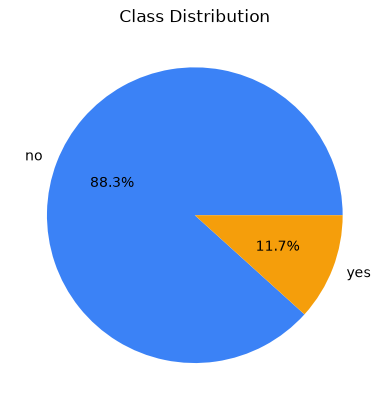

In [10]:
import matplotlib.pyplot as plt

class_counts = df['y'].value_counts()

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=['#3B82F6', '#F59E0B']
)

plt.title('Class Distribution')
plt.show()

###

### ***Univariate Analysis***

#### Numerical Features Distribution Analysis

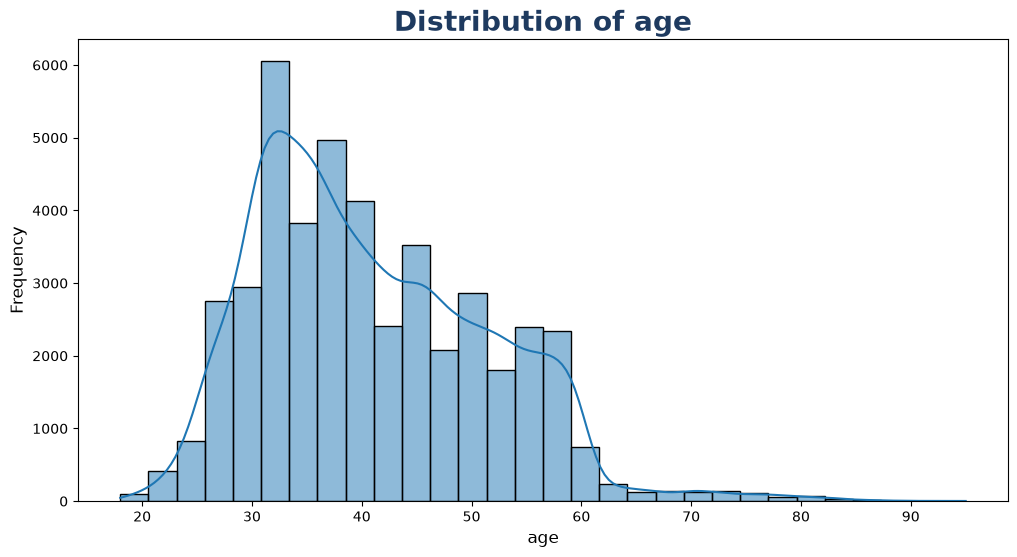

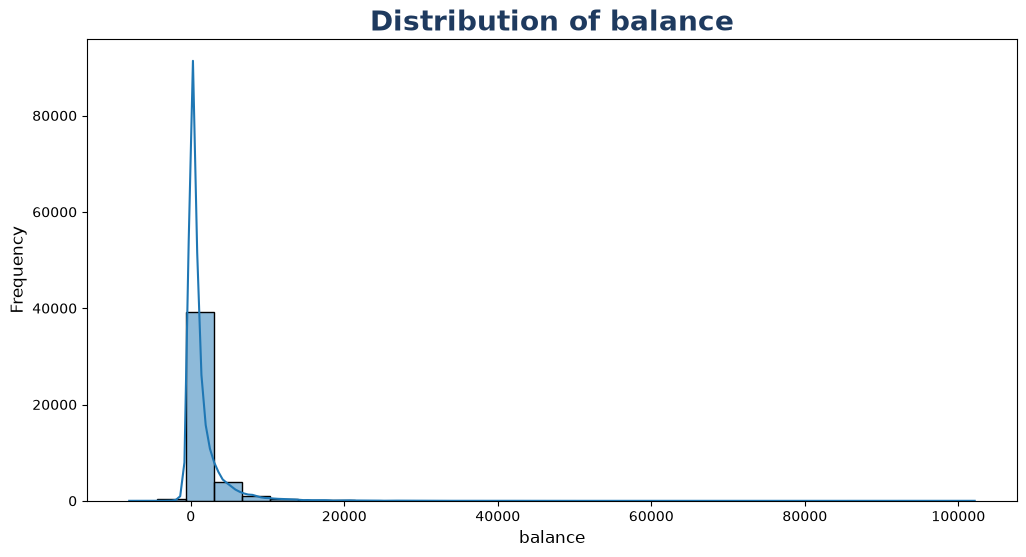

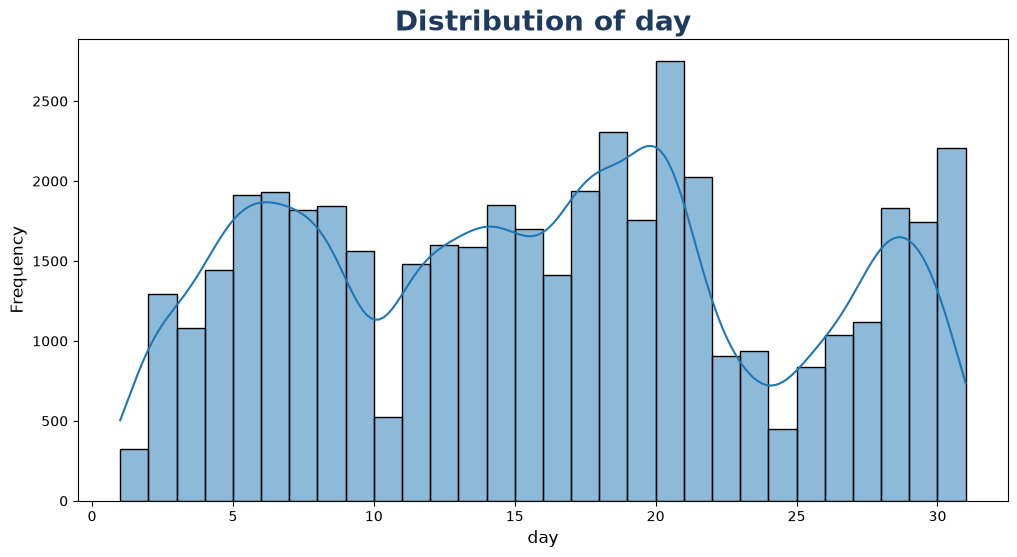

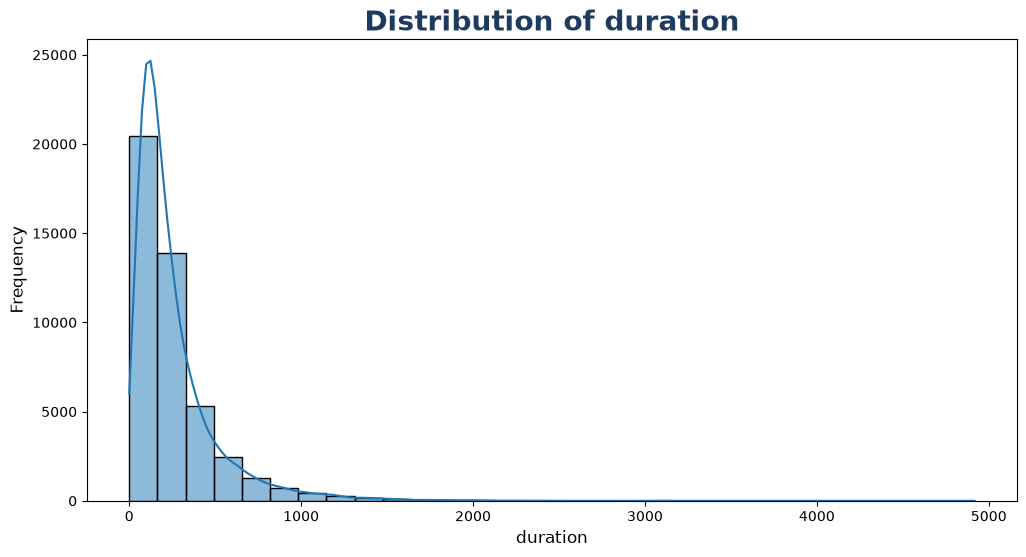

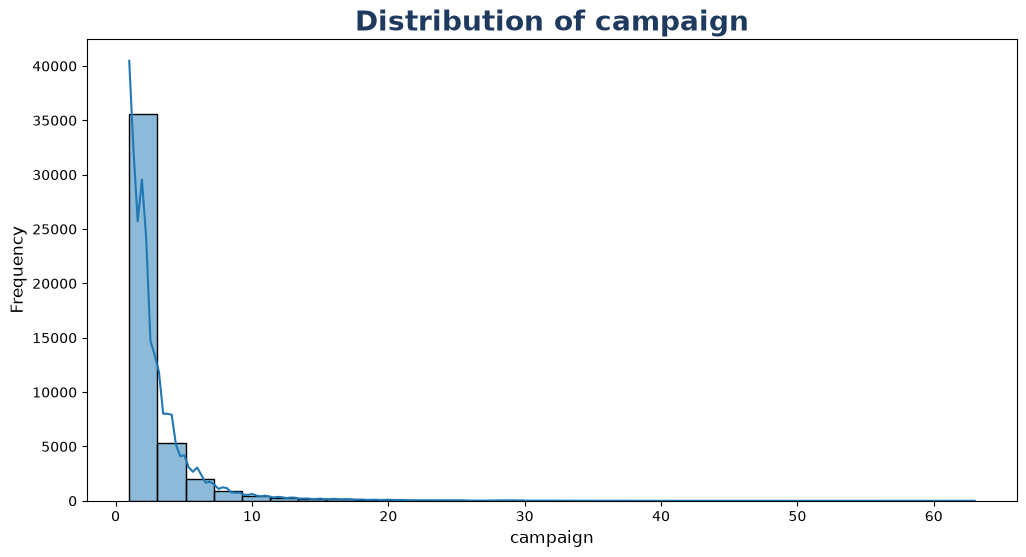

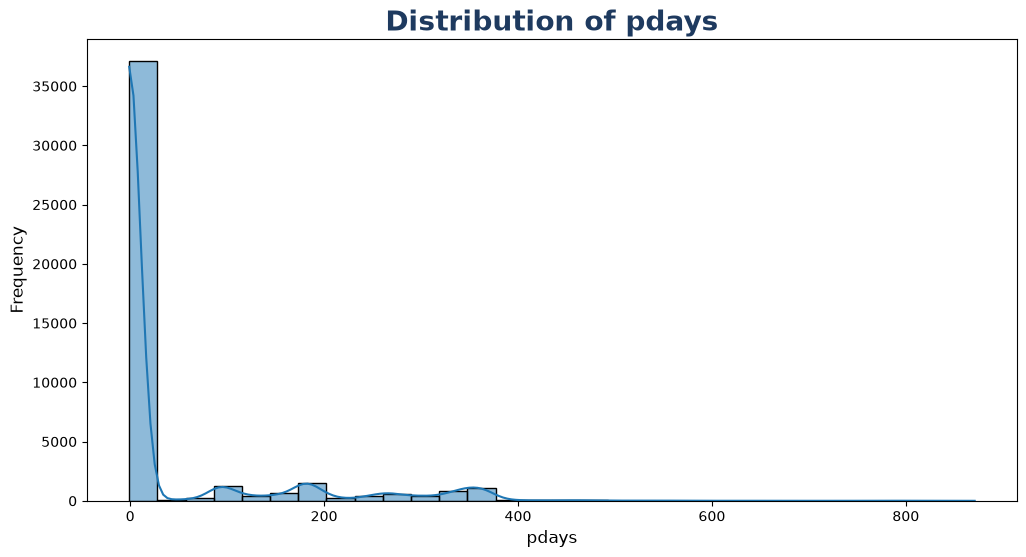

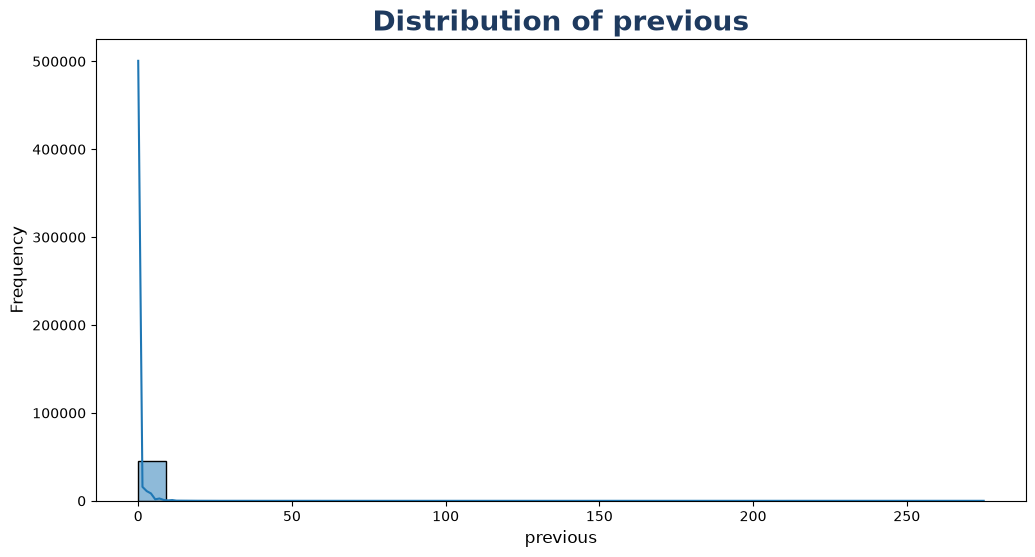

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64'])

for col in num_cols:
    plt.figure(figsize=(12, 6))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=20,
        fontweight='bold',
        color='#1E3A5F'
    )

    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.show()

#### **Categorical Features Distribution Analysis**

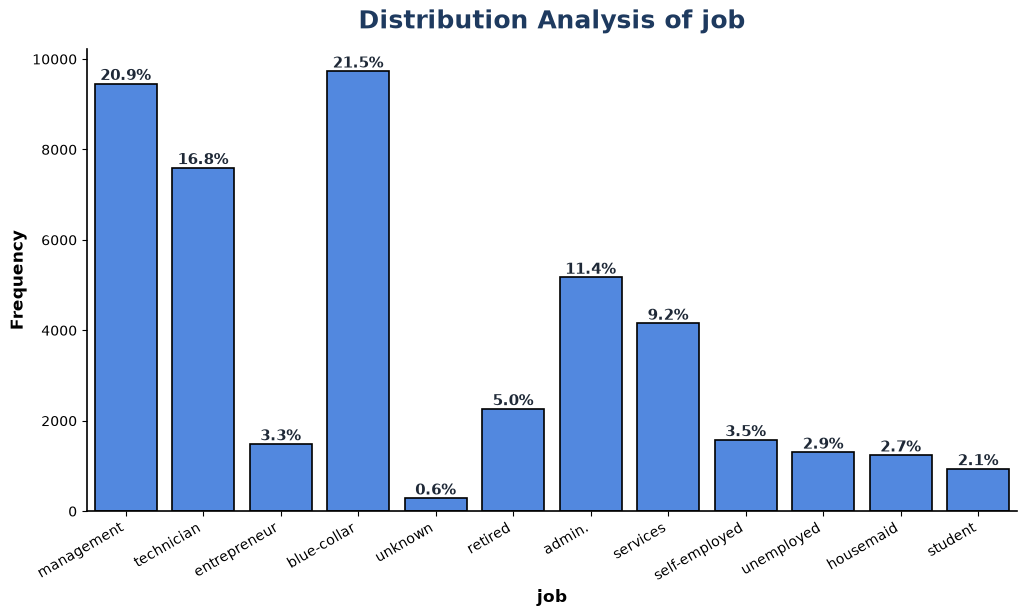

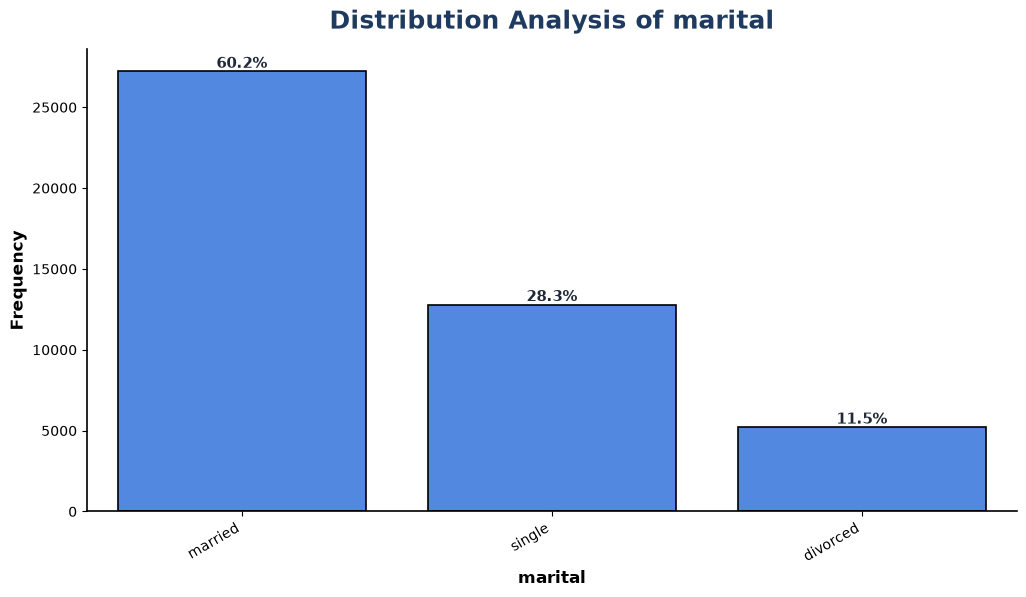

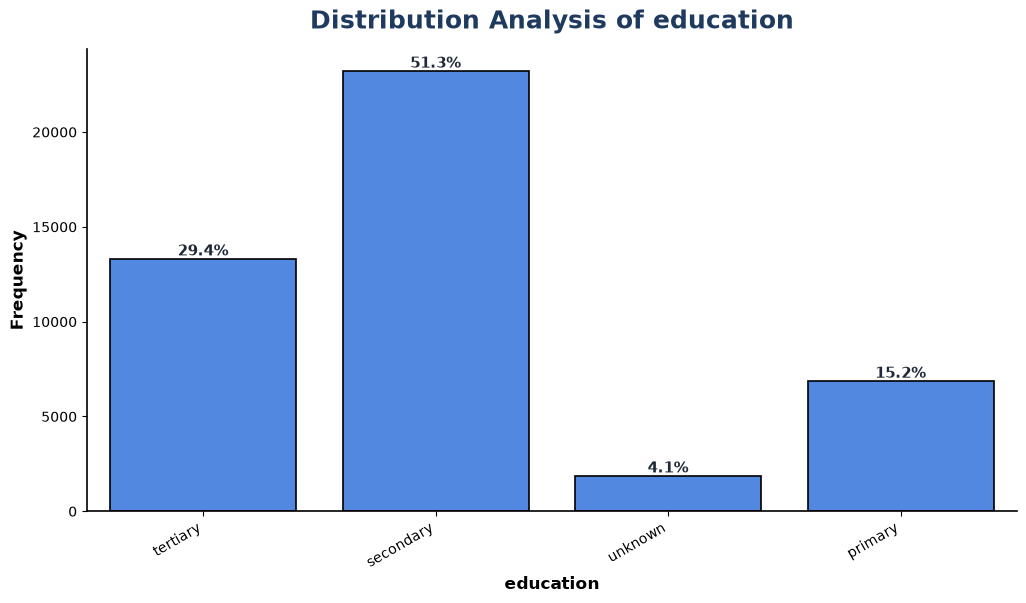

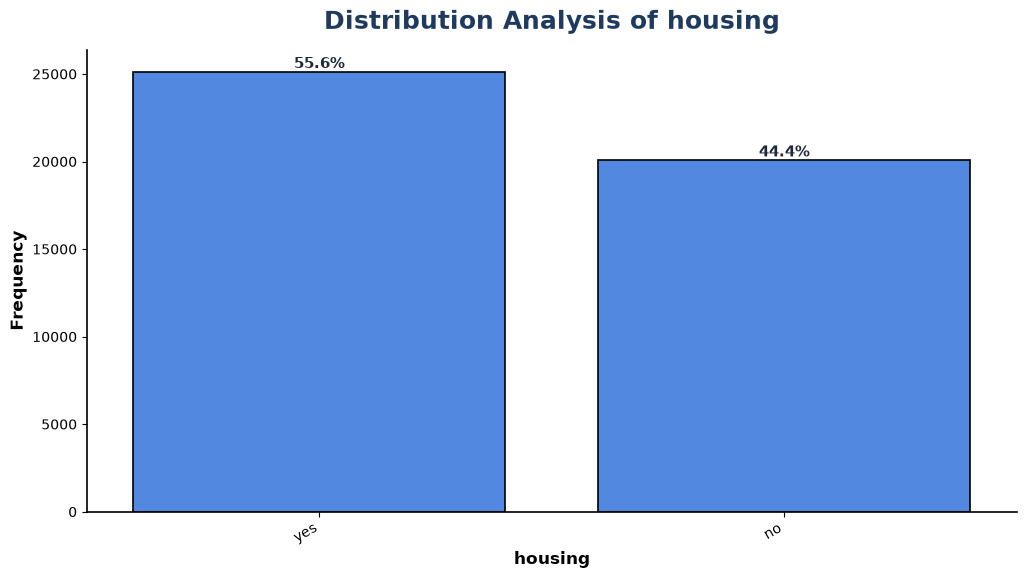

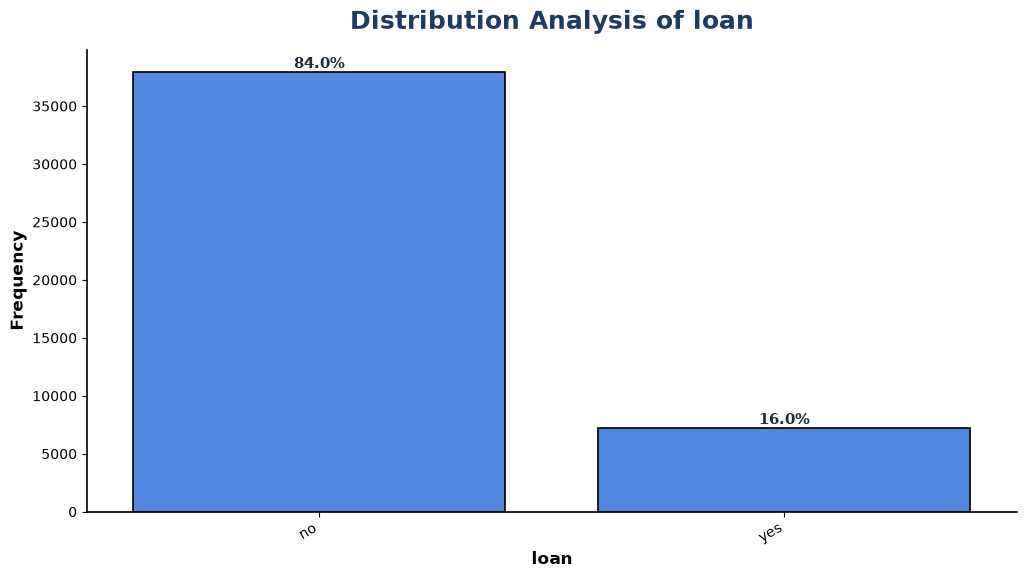

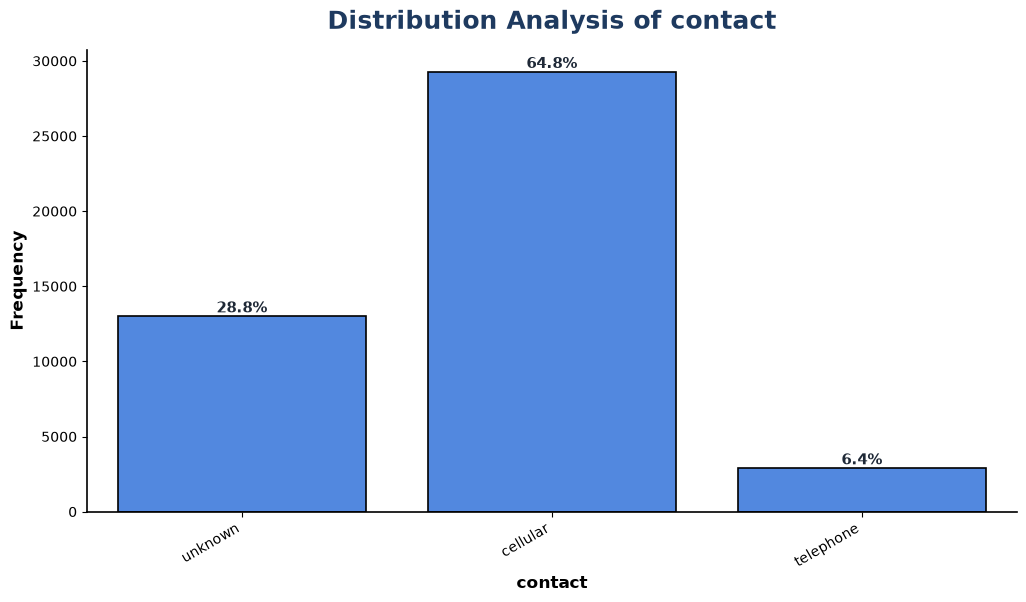

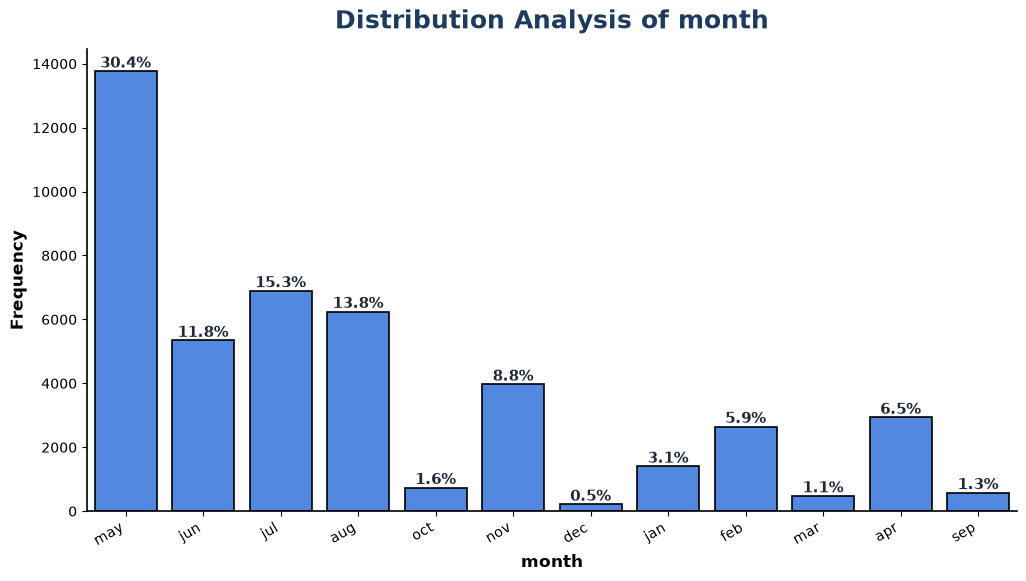

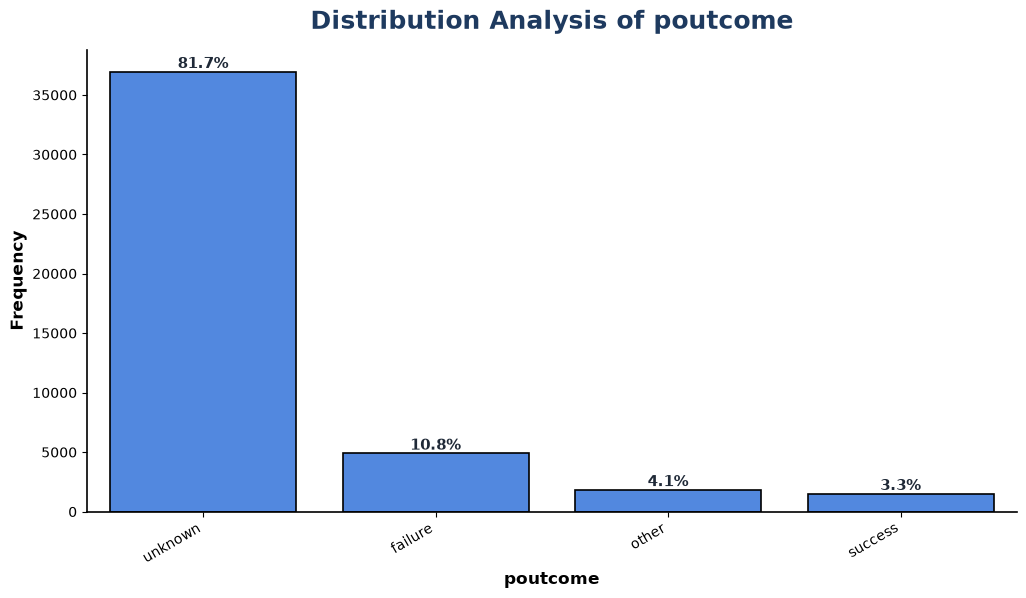

In [12]:
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in cat_cols:
    plt.figure(figsize=(12, 6))

    ax = sns.countplot(
        data=df,
        x=col,
        edgecolor='black',
        linewidth=1.2,
        color='#3B82F6'
    )

    total = len(df)

    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'

        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='#1F2937'
        )

    plt.title(
        f"Distribution Analysis of {col}",
        fontsize=18,
        fontweight='bold',
        color='#1E3A5F',
        pad=15
    )

    plt.xlabel(
        col,
        fontsize=12,
        fontweight='bold'
    )

    plt.ylabel(
        "Frequency",
        fontsize=12,
        fontweight='bold'
    )

    plt.xticks(
        rotation=30,
        ha='right'
    )

    ax = plt.gca()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    plt.show()

##

## **Bivariate Analysis**

#### Numerical Features Correlation with Target Variable

In [13]:
y_encoded = df['y'].map({'no': 0, 'yes': 1})

corr_matrix = df.select_dtypes(include='number').corrwith(y_encoded)

corr_matrix.sort_values(ascending=False)

duration    0.394521
pdays       0.103621
previous    0.093236
balance     0.052838
age         0.025155
day        -0.028348
campaign   -0.073172
dtype: float64

#### Numerical Features Distribution by Target Class

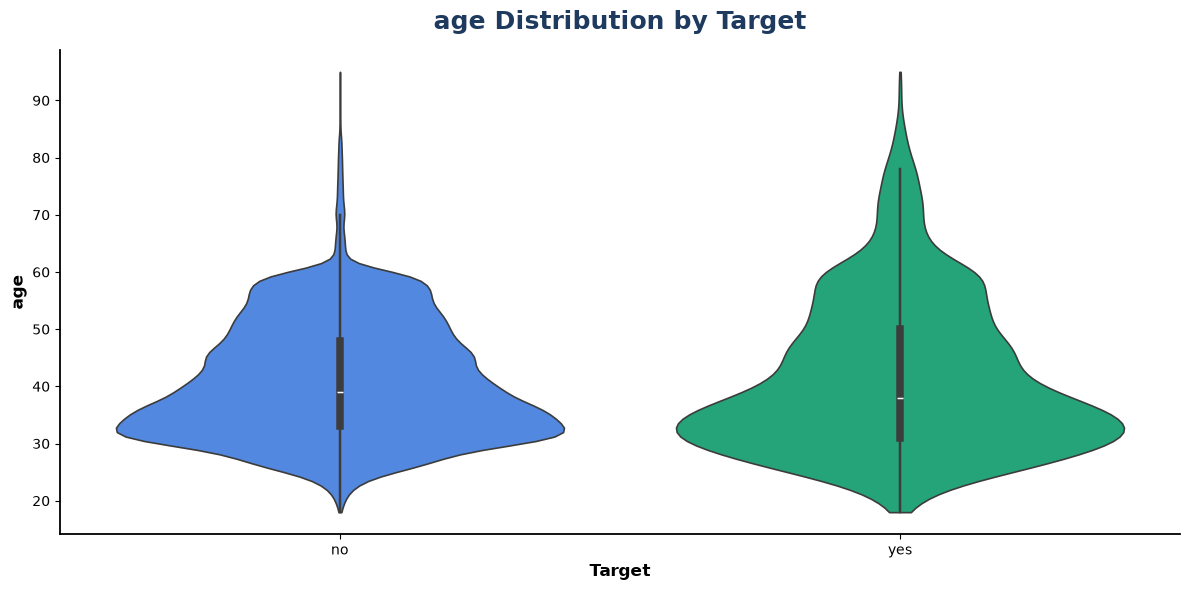

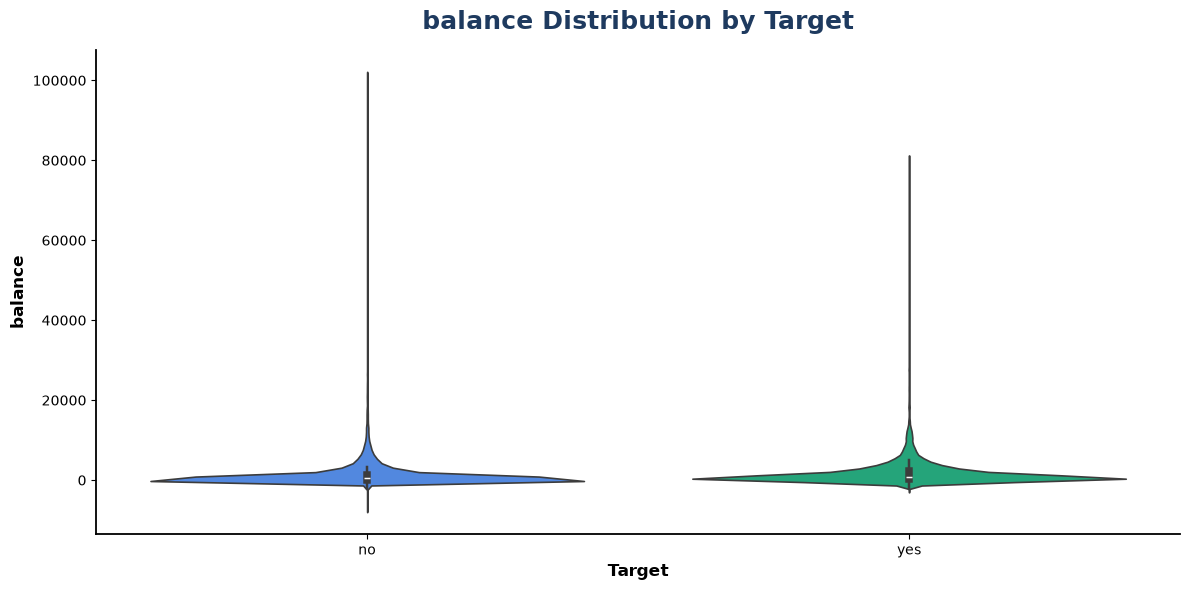

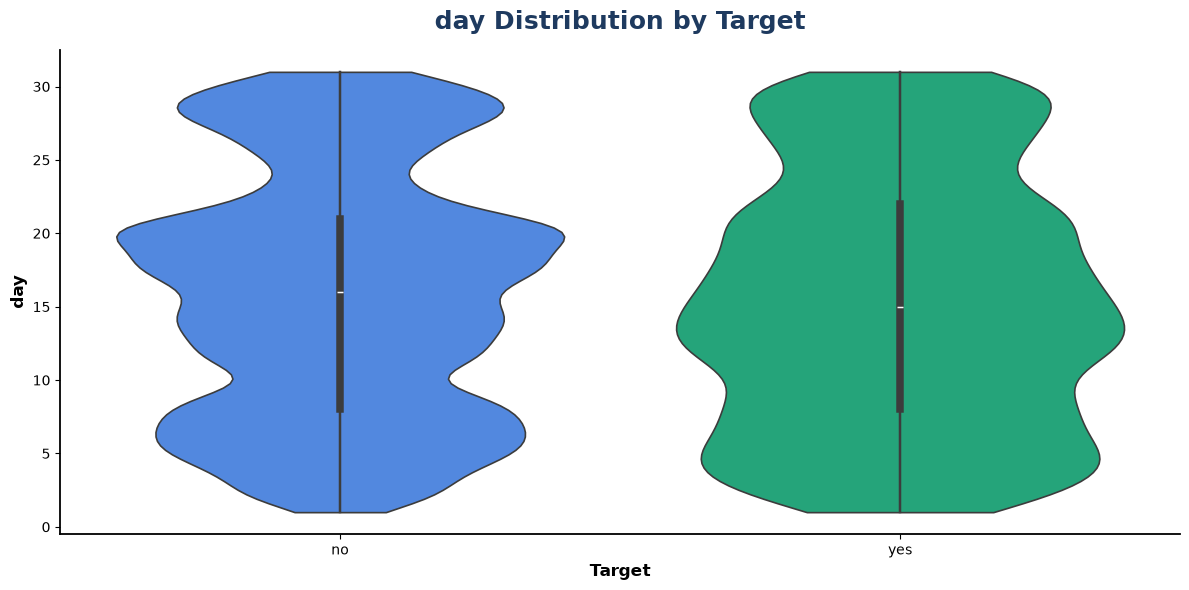

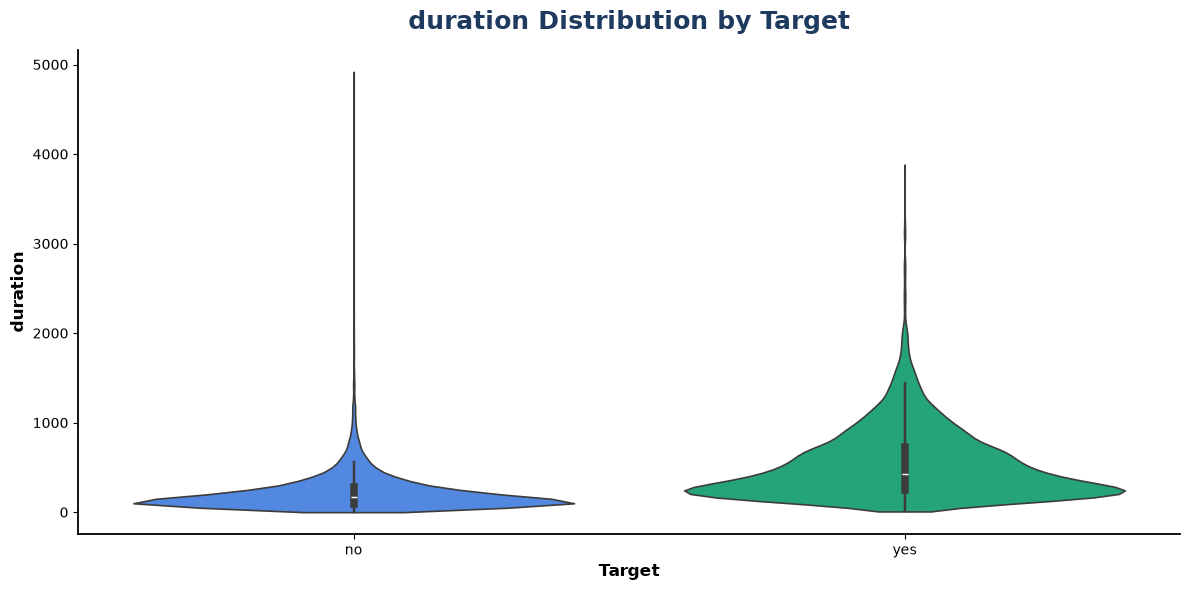

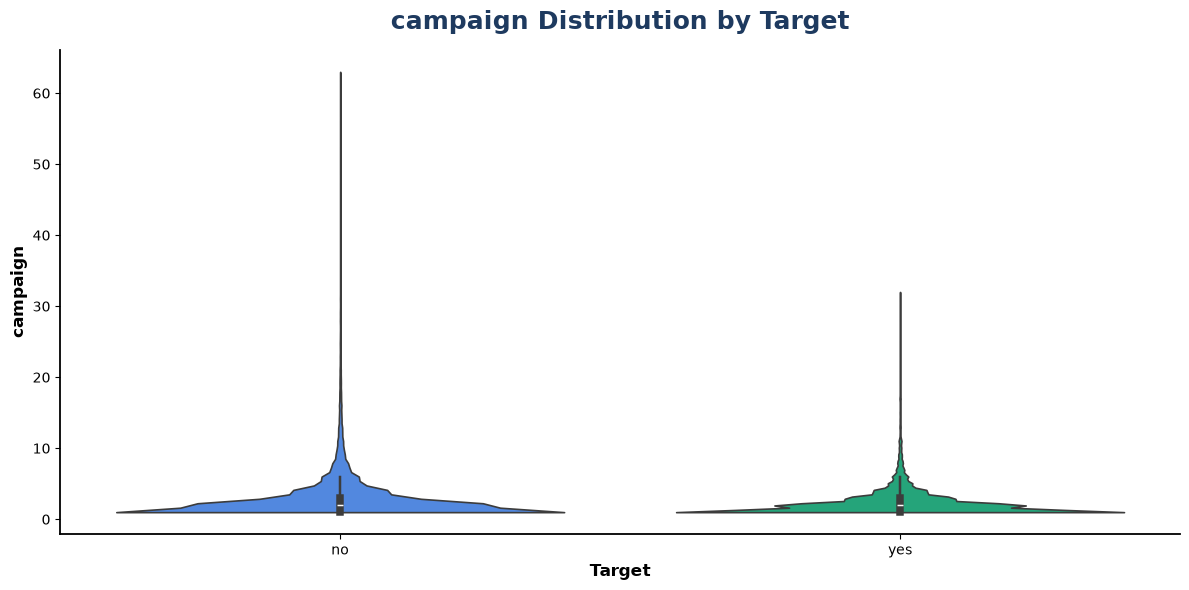

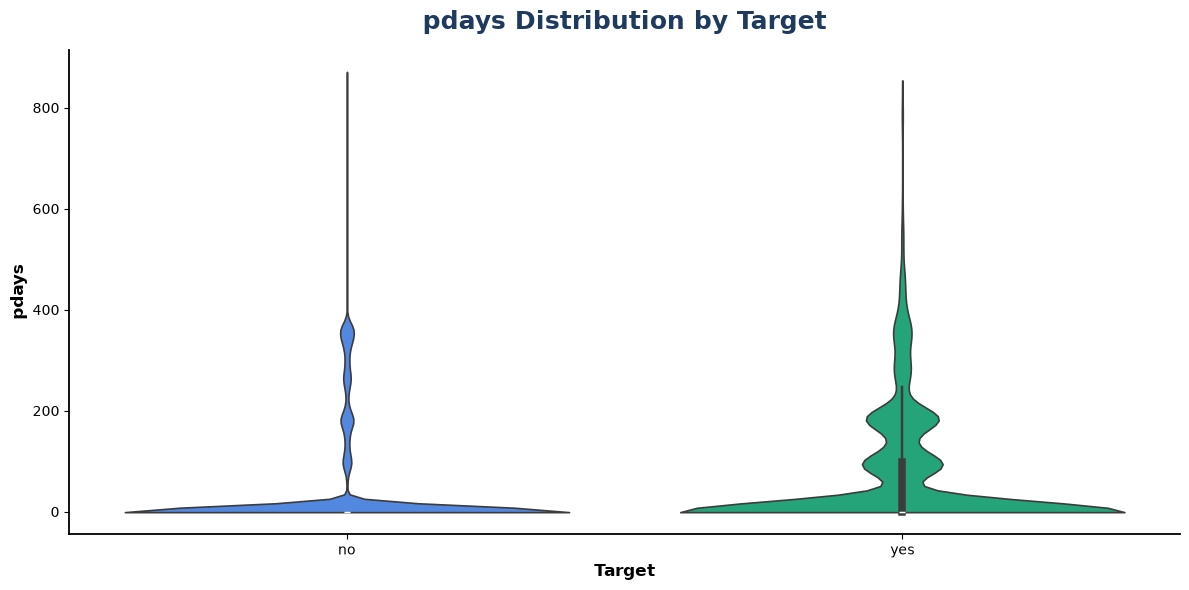

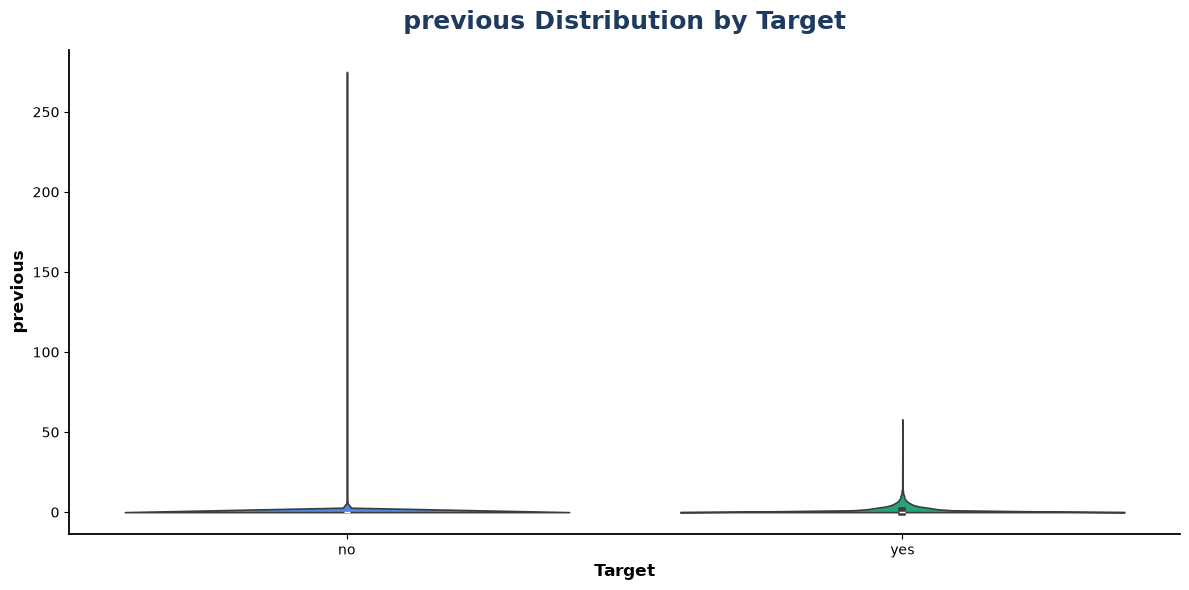

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

for col in num_cols:
    plt.figure(figsize=(12, 6))

    ax = sns.violinplot(
        data=df,
        x='y',
        y=col,
        hue='y',
        palette={
            'no': '#3B82F6',
            'yes': '#10B981'
        },
        inner='box',
        linewidth=1.2,
        cut=0,
        legend=False
    )

    plt.title(
        f'{col} Distribution by Target',
        fontsize=18,
        fontweight='bold',
        color='#1E3A5F',
        pad=15
    )

    plt.xlabel(
        'Target',
        fontsize=12,
        fontweight='bold'
    )

    plt.ylabel(
        col,
        fontsize=12,
        fontweight='bold'
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_linewidth(1.3)
    ax.spines['bottom'].set_linewidth(1.3)

    plt.tight_layout()
    plt.show()

###

#### Categorical Features Distribution by Target Class

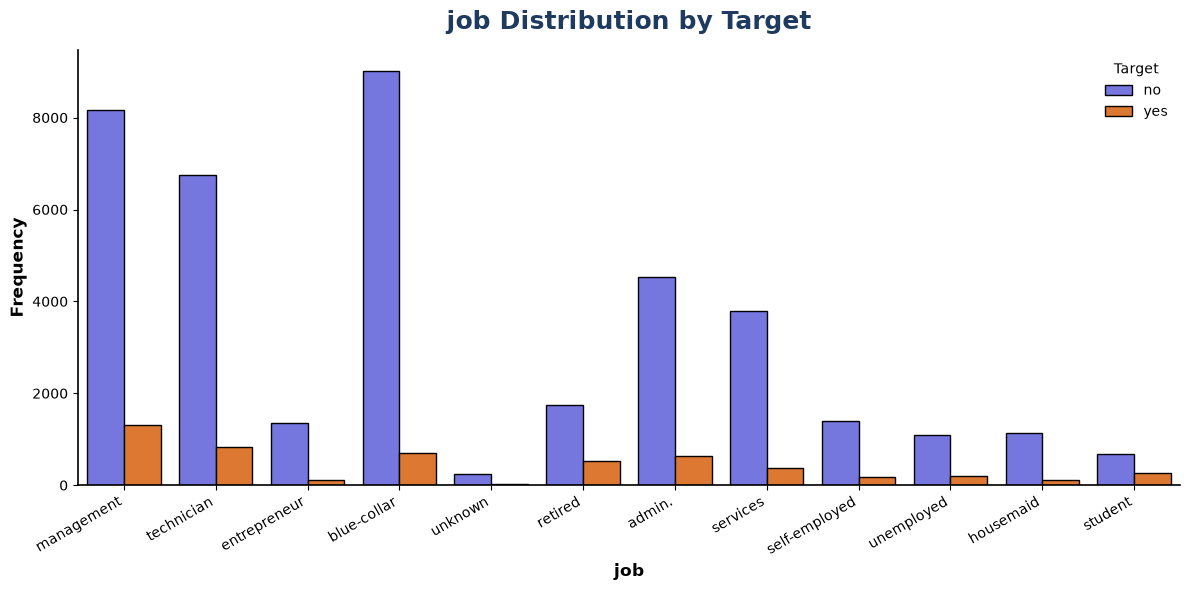

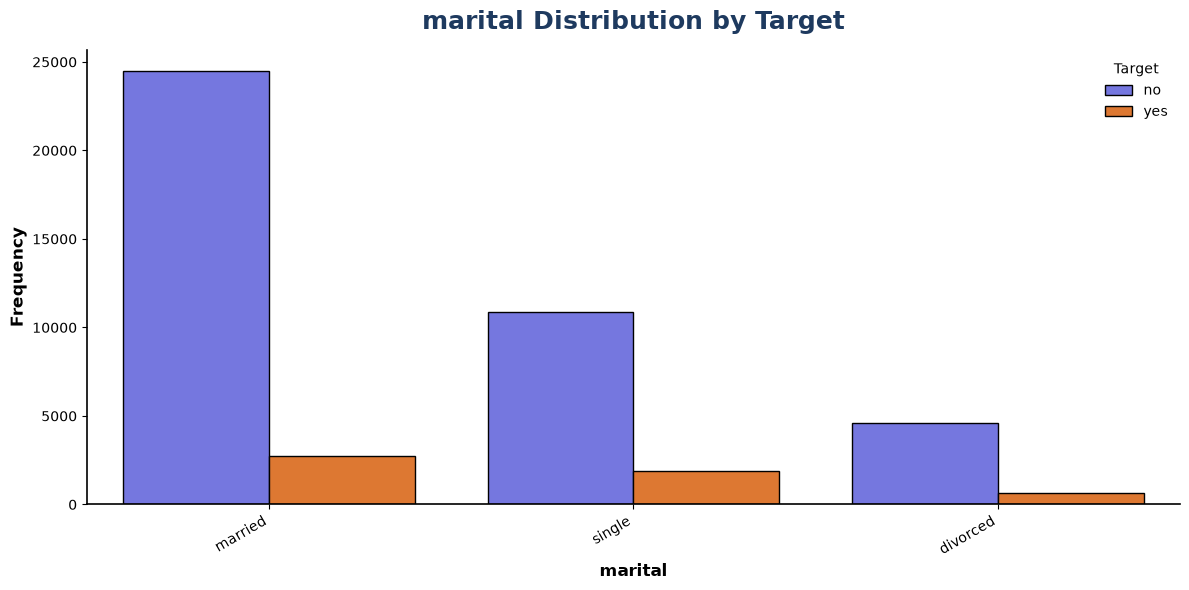

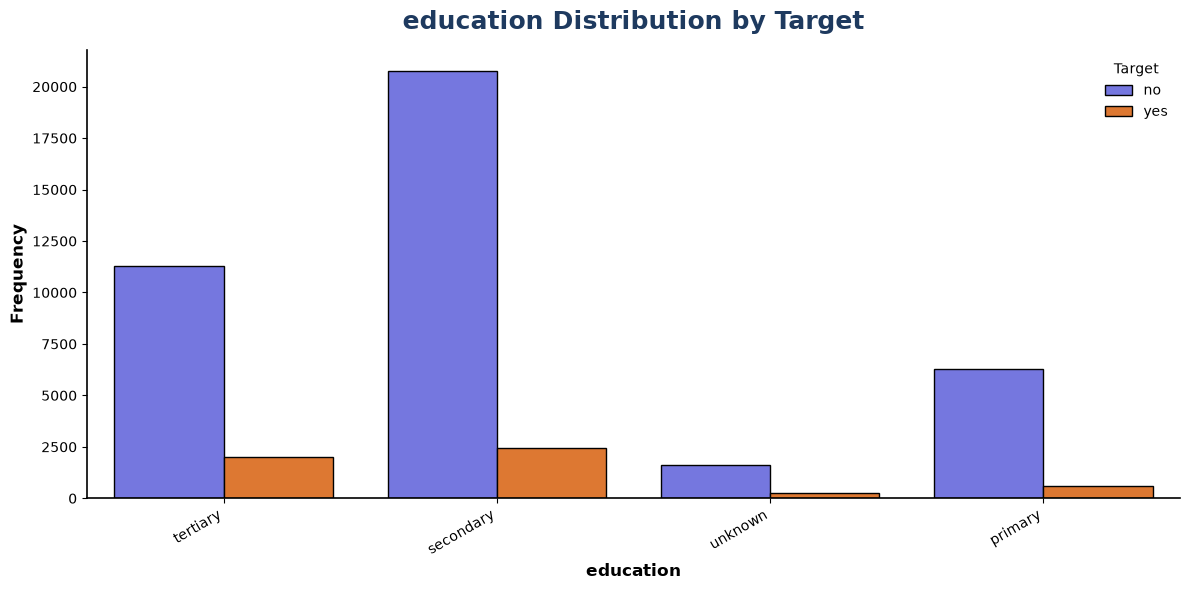

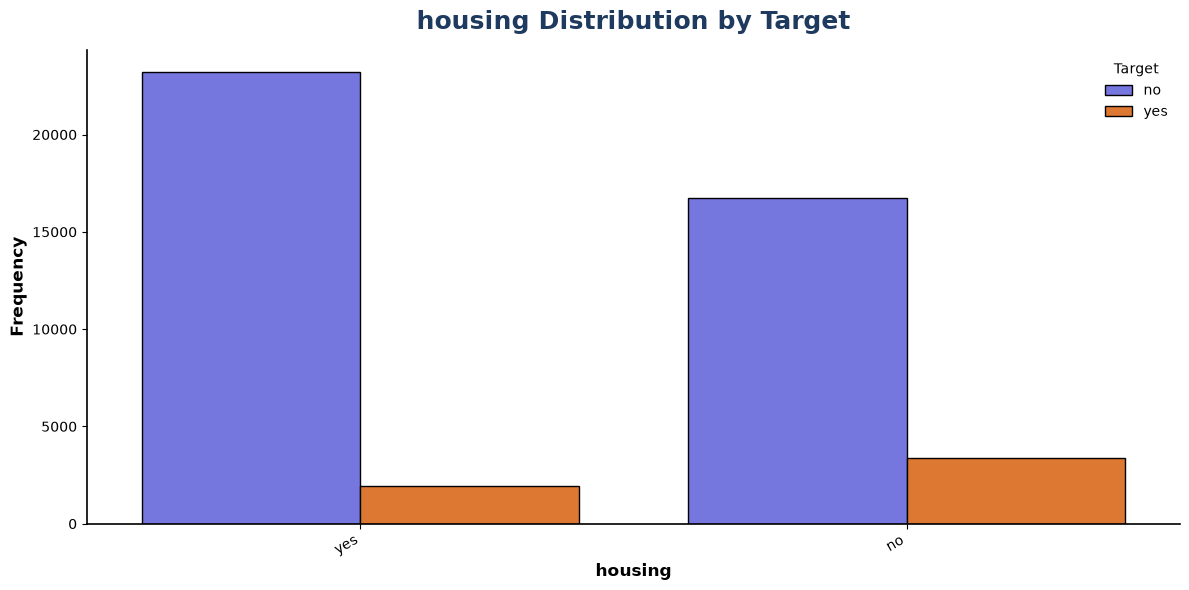

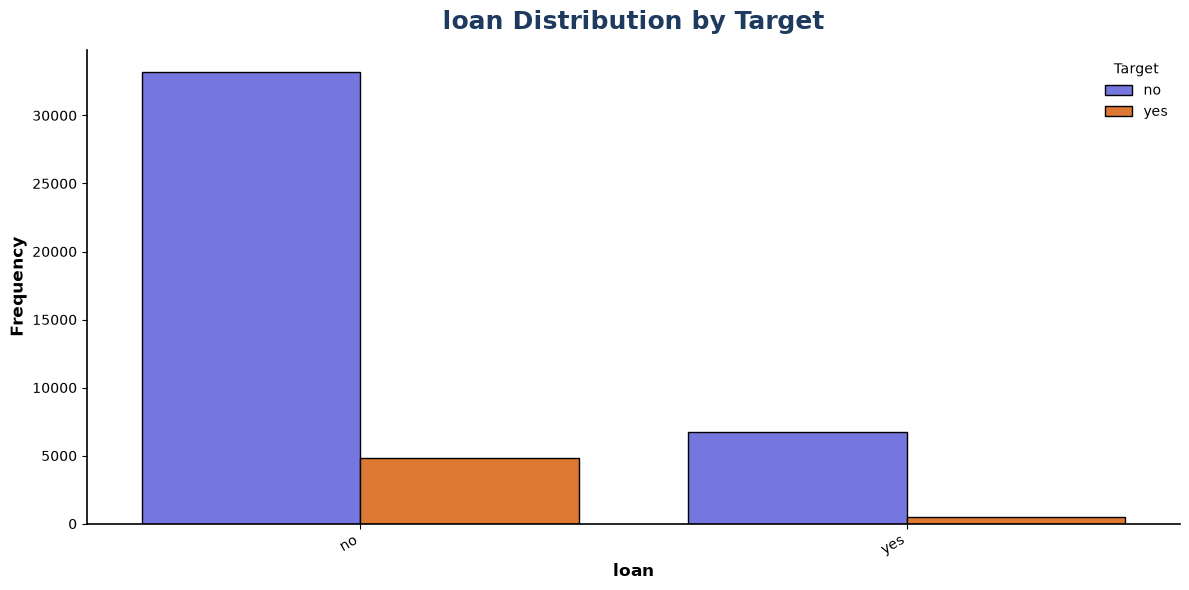

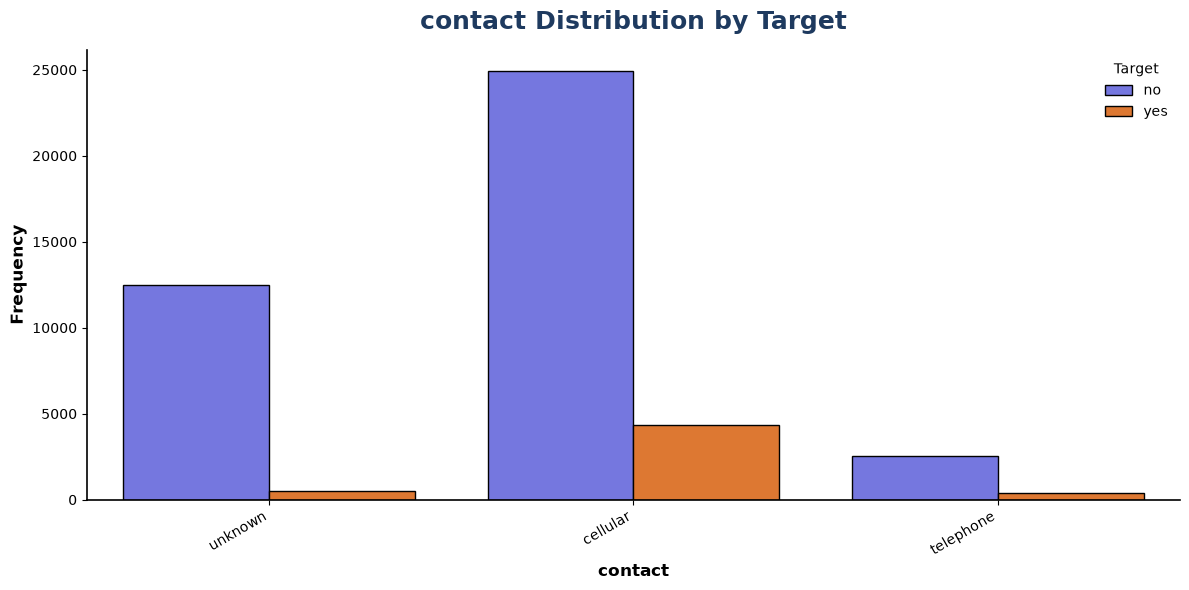

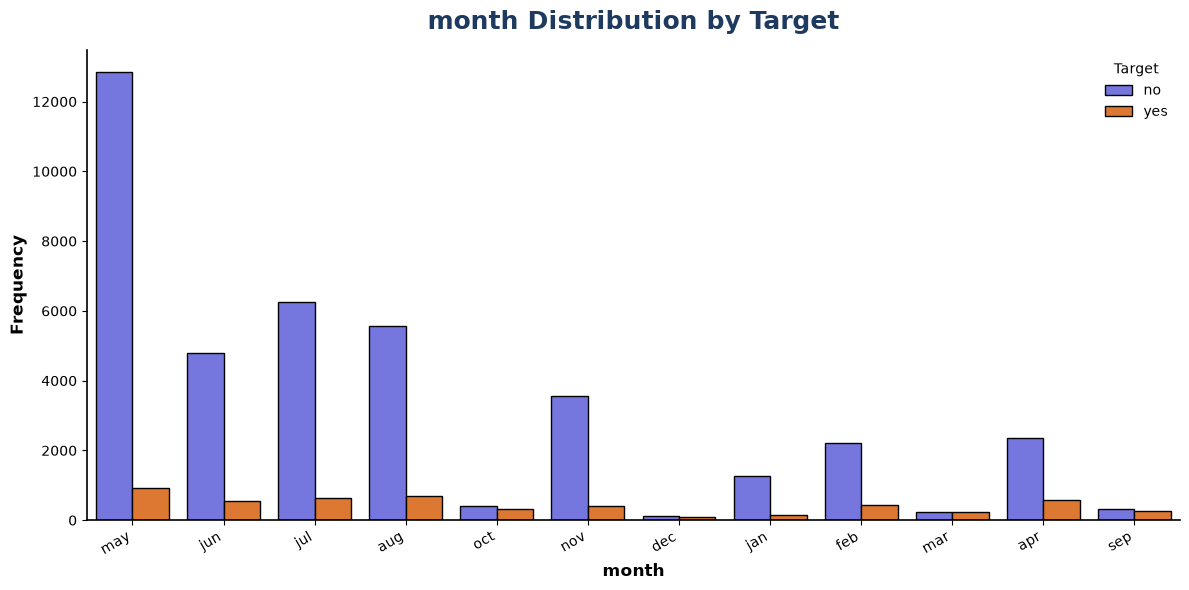

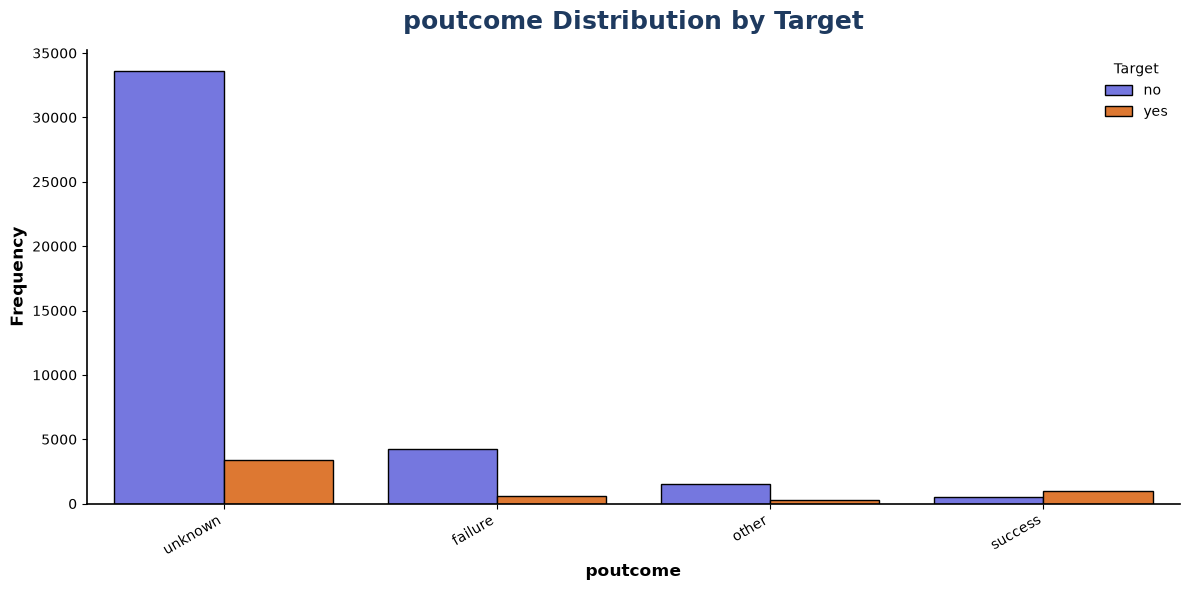

In [15]:
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in cat_cols:
    plt.figure(figsize=(12, 6))

    ax = sns.countplot(
        data=df,
        x=col,
        hue='y',
        hue_order=['no', 'yes'],
        palette={
            'no': '#6366F1',
            'yes': '#F97316'
        },
        edgecolor='black',
        linewidth=1.0
    )

    plt.title(
        f'{col} Distribution by Target',
        fontsize=18,
        fontweight='bold',
        color='#1E3A5F',
        pad=15
    )

    plt.xlabel(
        col,
        fontsize=12,
        fontweight='bold'
    )

    plt.ylabel(
        'Frequency',
        fontsize=12,
        fontweight='bold'
    )

    plt.xticks(
        rotation=30,
        ha='right'
    )

    plt.legend(
        title='Target',
        frameon=False
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    plt.show()

###

#### Correlation Analysis of Numerical Features and Target Variable

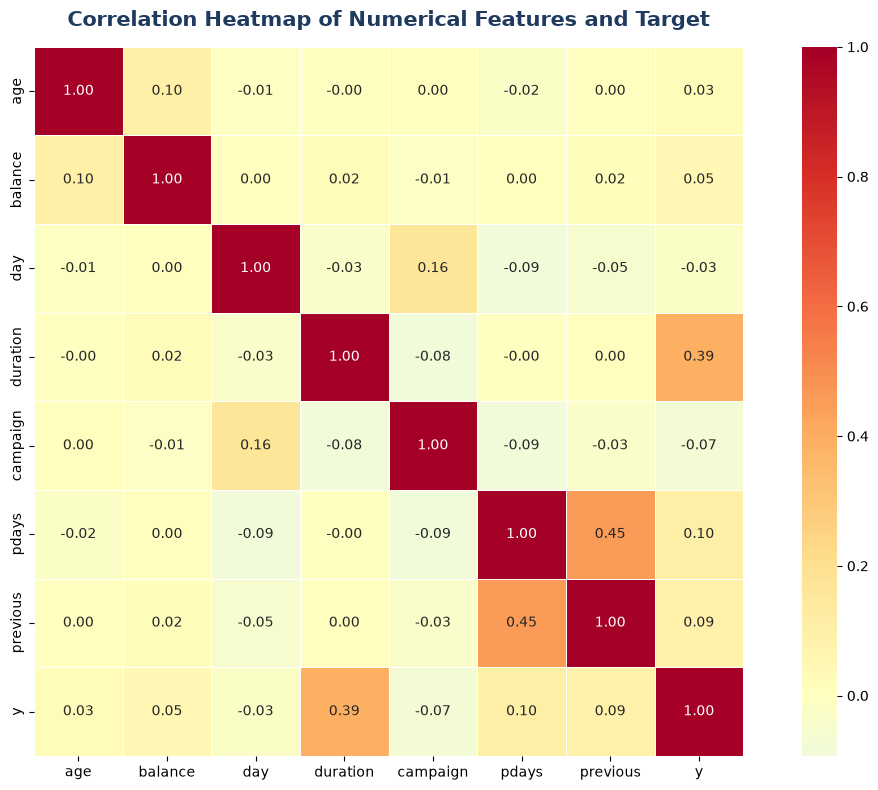

In [16]:
# Temporary encoding of target variable
y_encoded = df['y'].map({
    'no': 0,
    'yes': 1
})

# Create correlation matrix
corr_data = df.select_dtypes(include=['int64', 'float64']).copy()
corr_data['y'] = y_encoded

corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Numerical Features and Target',
    fontsize=15,
    fontweight='bold',
    color='#1E3A5F',
    pad=15
)

plt.tight_layout()
plt.show()

##

### **Multivariate Analysis**

#### Numerical Features Relationship Analysis

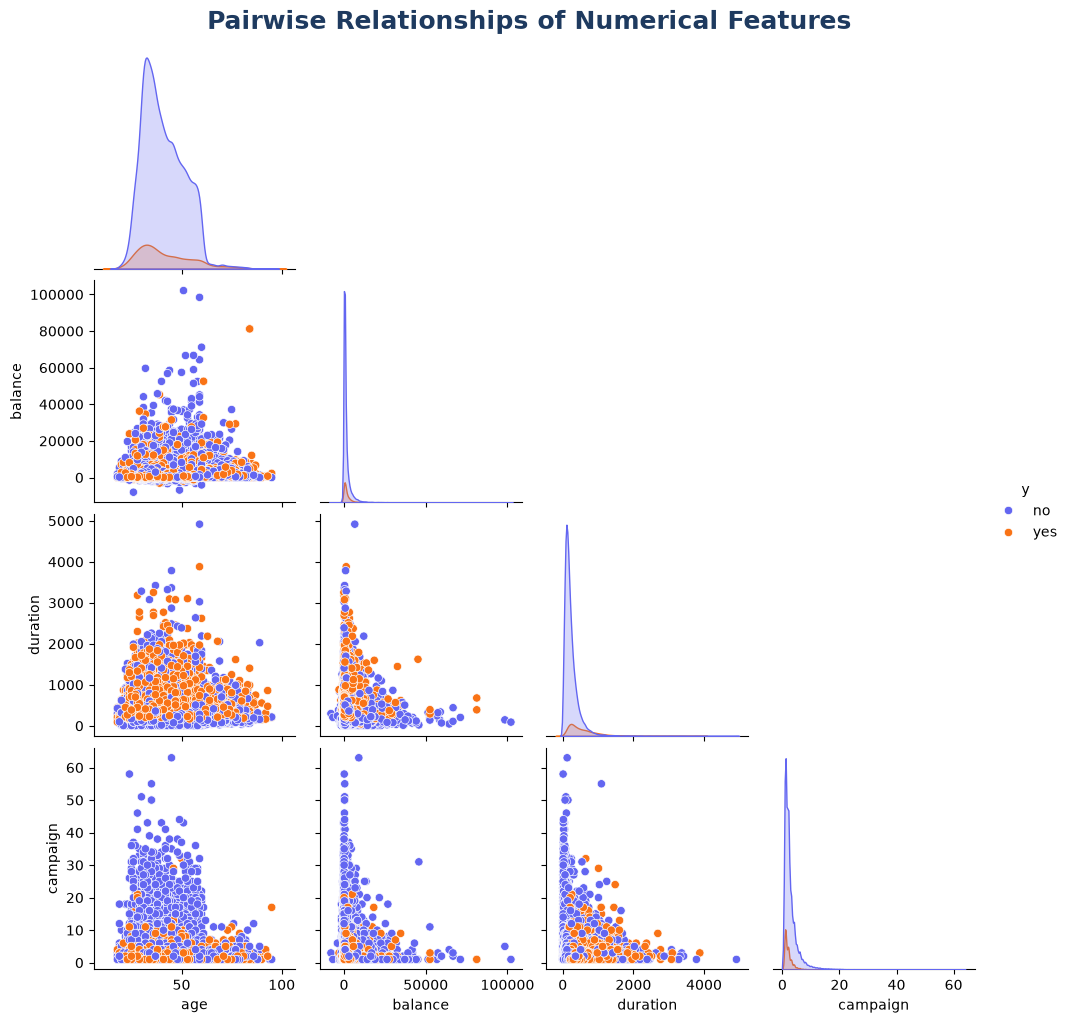

In [17]:
num_cols = ['age', 'balance', 'duration', 'campaign']

sns.pairplot(
    data=df,
    vars=num_cols,
    hue='y',
    palette={
        'no': '#6366F1',
        'yes': '#F97316'
    },
    diag_kind='kde',
    corner=True
)

plt.suptitle(
    'Pairwise Relationships of Numerical Features',
    fontsize=18,
    fontweight='bold',
    color='#1E3A5F',
    y=1.02
)

plt.show()

###

#### Numerical Features Outlier Analysis

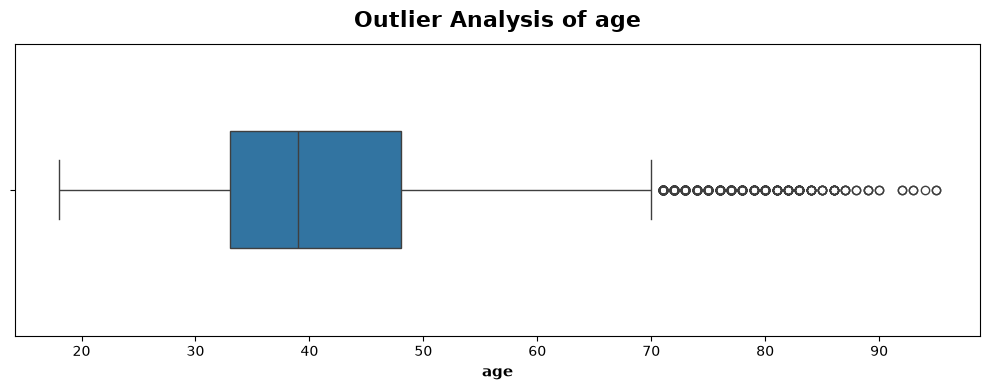

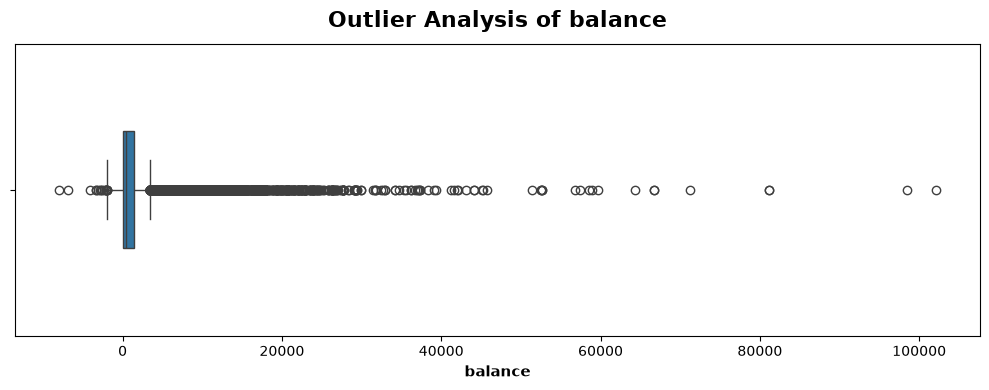

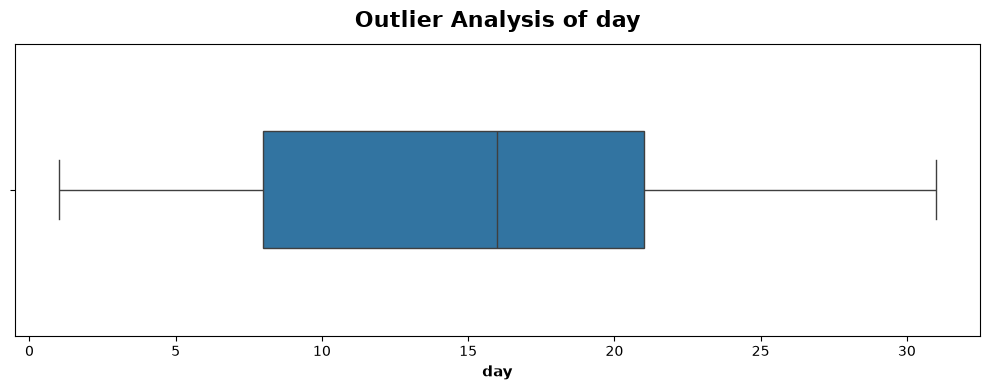

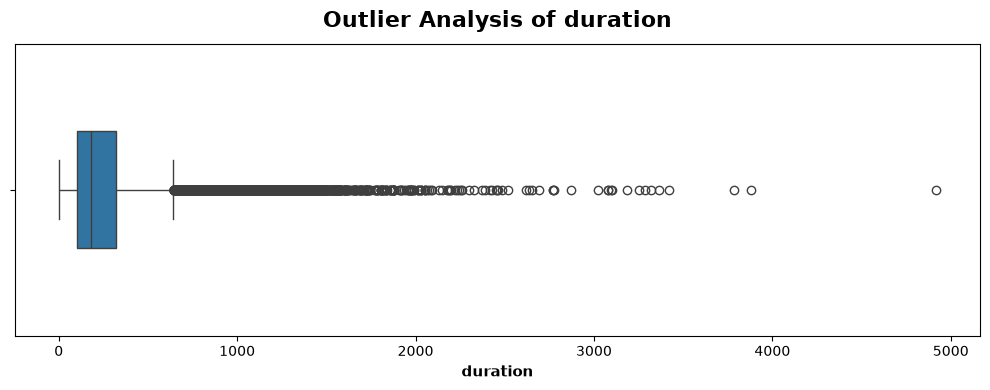

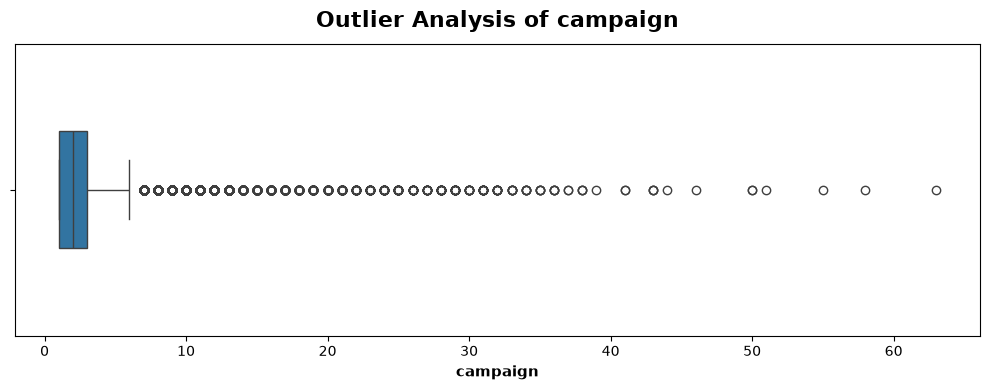

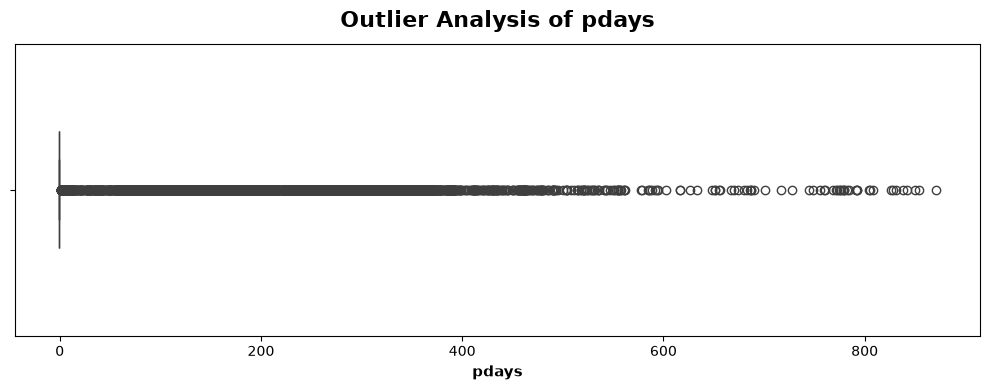

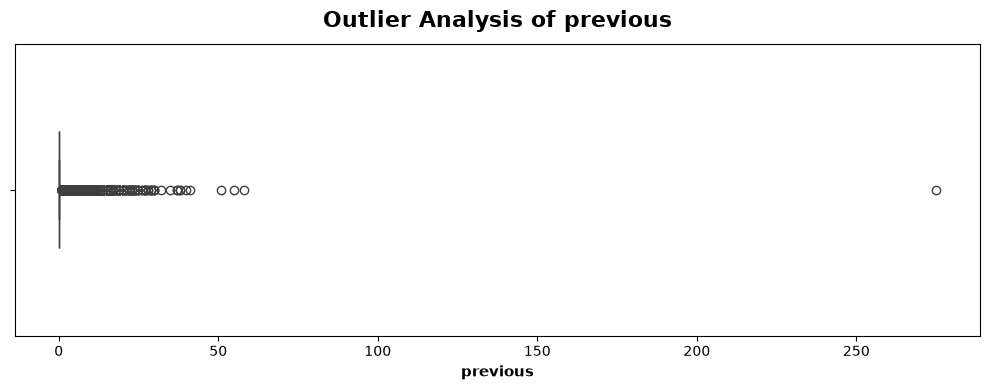

In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10, 4))

    ax = sns.boxplot(
        x=df[col],
        width=0.4
    )

    plt.title(
        f'Outlier Analysis of {col}',
        fontsize=16,
        fontweight='bold',
        pad=12
    )

    plt.xlabel(
        col,
        fontsize=11,
        fontweight='bold'
    )


    plt.tight_layout()
    plt.show()

#### Outlier Treatment Using IQR Clipping

In [19]:
cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

#### Outlier Treatment Verification

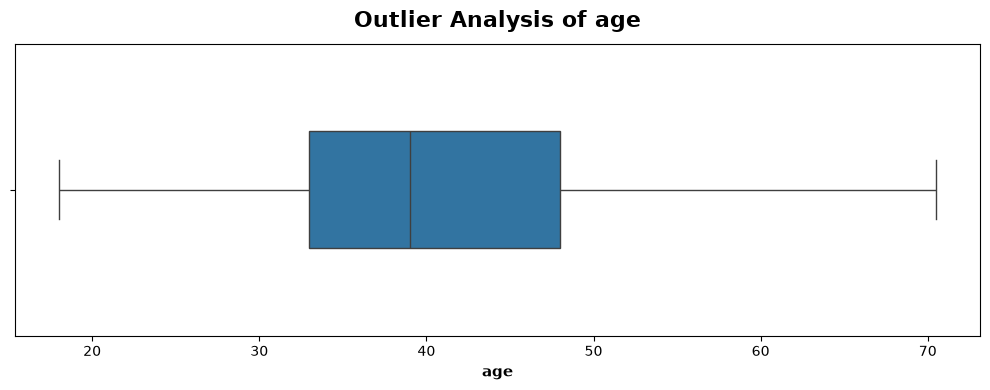

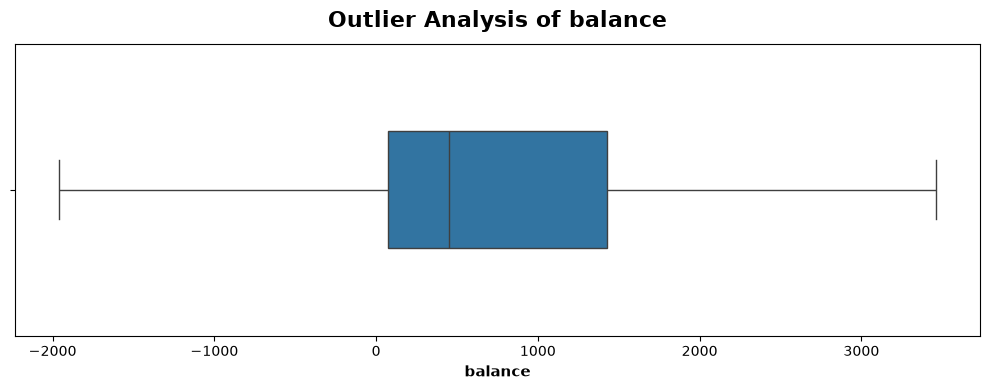

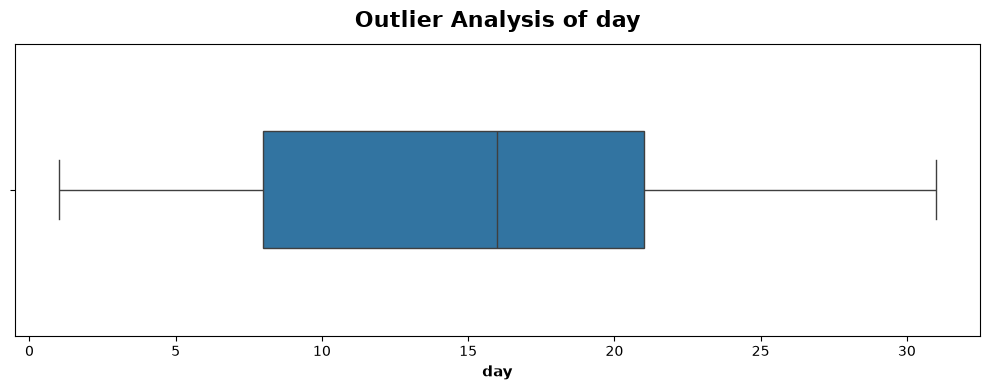

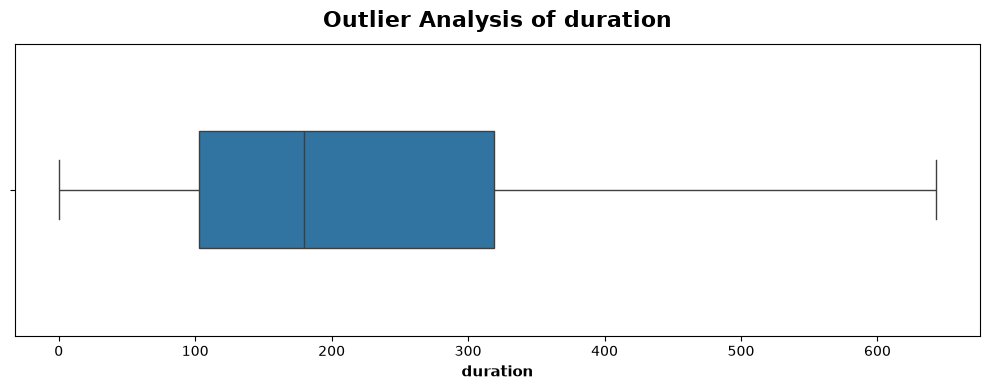

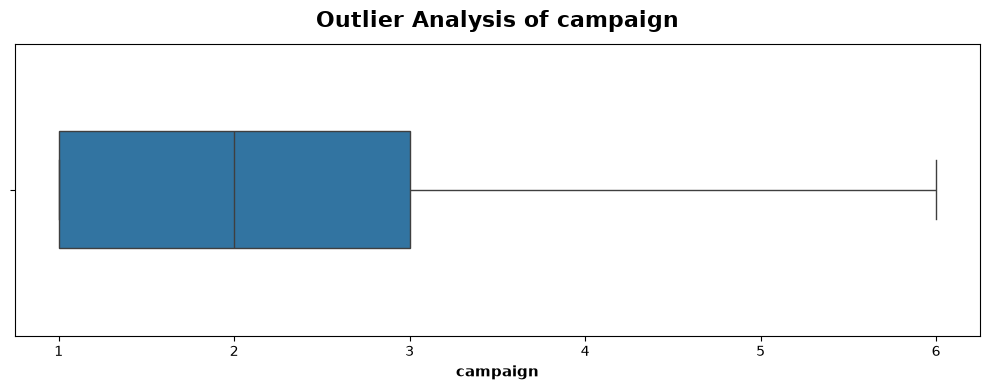

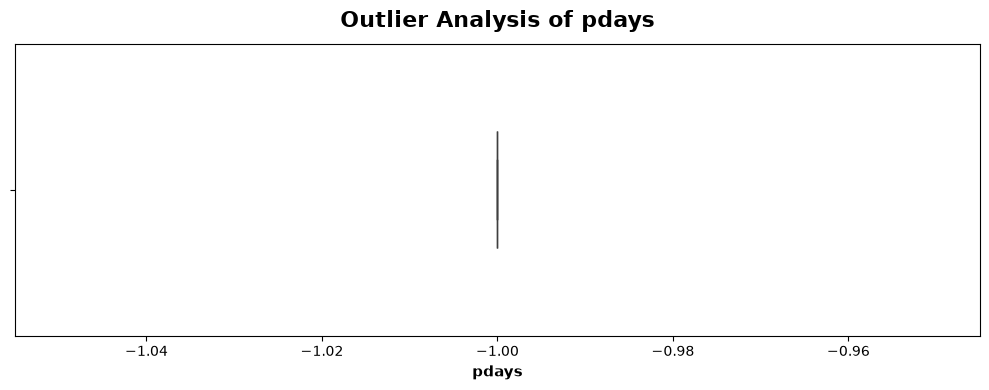

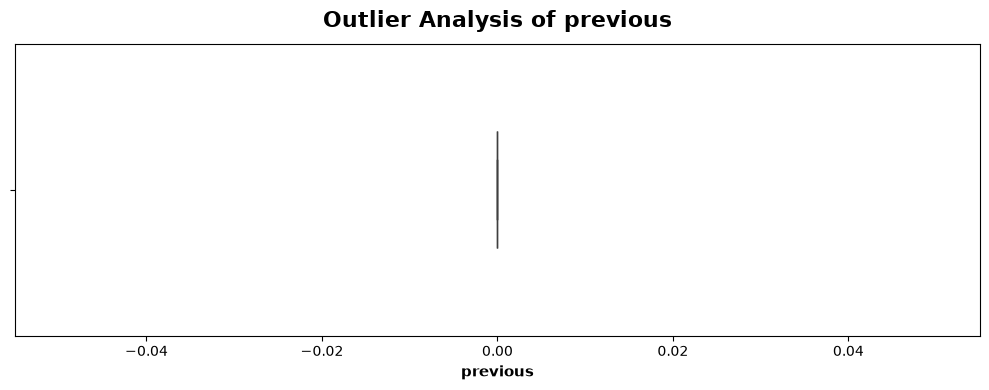

In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10, 4))

    ax = sns.boxplot(
        x=df[col],
        width=0.4
    )

    plt.title(
        f'Outlier Analysis of {col}',
        fontsize=16,
        fontweight='bold',
        pad=12
    )

    plt.xlabel(
        col,
        fontsize=11,
        fontweight='bold'
    )


    plt.tight_layout()
    plt.show()

##

#### Removing Constant Features

In [21]:
df = df.drop(columns=['pdays', 'previous'], axis=1)

###

### Feature and Target Separation

In [22]:
X = df.drop('y', axis=1)

y = df['y']

### Encoding Categorical Features and Target Variable

In [23]:
# One-Hot Encoding for Categorical Features
X = pd.get_dummies(
    X,
    columns=[
        'job', 'marital', 'education', 'default',
        'housing', 'loan', 'contact', 'month', 'poutcome'
    ],
    drop_first=True,
    dtype=int
)

# Binary Encoding of Target Variable
y = y.apply(
    lambda x: 1 if x == 'yes' else 0
)

###

### Splitting Data into Training and Testing Sets

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Feature Scaling Using StandardScaler

In [25]:
from sklearn.preprocessing import StandardScaler

cols = ['age', 'balance', 'day', 'duration', 'campaign']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])

###

## **Logistic Regression**

#### Logistic Regression Model Training

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#### Logistic Regression Predictions

In [27]:
y_pred_lr = lr_model.predict(X_test_scaled)

#### Logistic Regression Model Evaluation

Accuracy Score: 0.8971580227800509


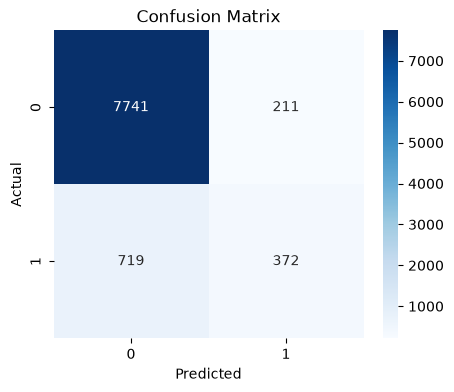

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.34      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

as_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cr_lr = classification_report(y_test, y_pred_lr)

# Accuracy
print("Accuracy Score:", as_lr)

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n", cr_lr)

#### Logistic Regression Log Loss Evaluation

In [29]:
from sklearn.metrics import log_loss

y_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]

log_loss_lr = log_loss(y_test, y_proba_lr)
print("Log Loss:", log_loss_lr)

Log Loss: 0.23609423263525206


#### ROC Curve and AUC Score Analysis

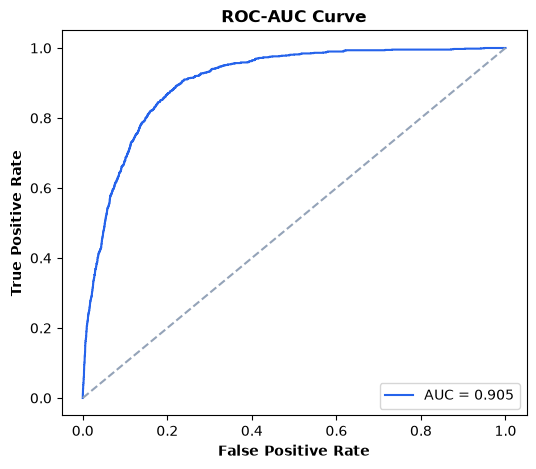

ROC-AUC Score: 0.9048438200237169


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_lr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1],[0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

#### Precision-Recall Curve and Average Precision Analysis

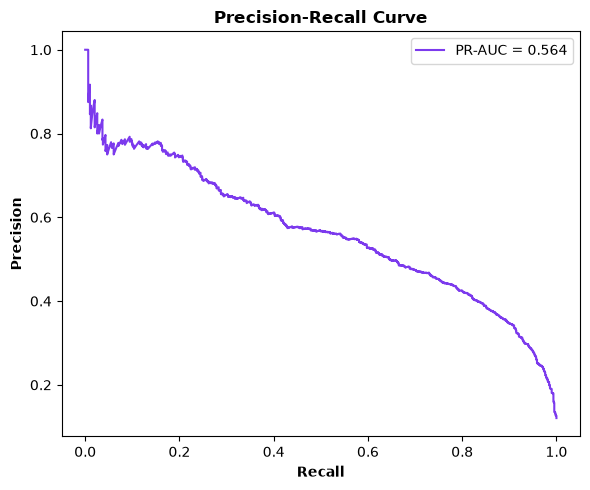

PR-AUC Score: 0.5644683501379776


In [86]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_lr)

# Plot
plt.figure(figsize=(6, 5))

plt.plot(recall, precision, color='#7C3AED', label=f'PR-AUC = {pr_auc:.3f}')

plt.title('Precision-Recall Curve',fontsize=12,fontweight='bold')
plt.xlabel('Recall', fontweight='bold')
plt.ylabel('Precision', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **K-Nearest Neighbors (KNN)**

#### K-Nearest Neighbors (KNN) Model Training

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### KNN Model Predictions

In [33]:
y_pred_knn = knn_model.predict(X_test_scaled)

#### KNN Model Evaluation

Accuracy Score: 0.8910759703638174


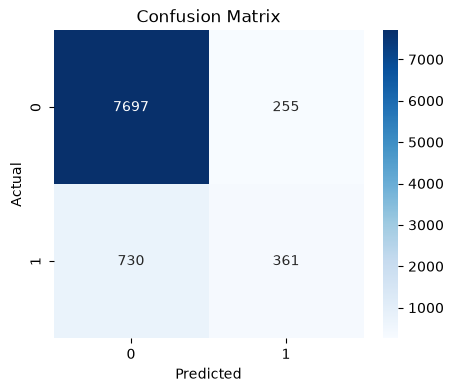

Classification Report:               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.59      0.33      0.42      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.65      0.68      9043
weighted avg       0.87      0.89      0.88      9043



In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

as_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cr_knn = classification_report(y_test, y_pred_knn)

# Accuracy
print("Accuracy Score:", as_knn)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("Classification Report:", cr_knn)

#### KNN Log Loss Evaluation

In [35]:
from sklearn.metrics import log_loss

y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

log_loss_knn = log_loss(y_test, y_proba_knn)
print("Log Loss:", log_loss_knn)

Log Loss: 0.9803855021147527


#### KNN ROC Curve and AUC Score Analysis

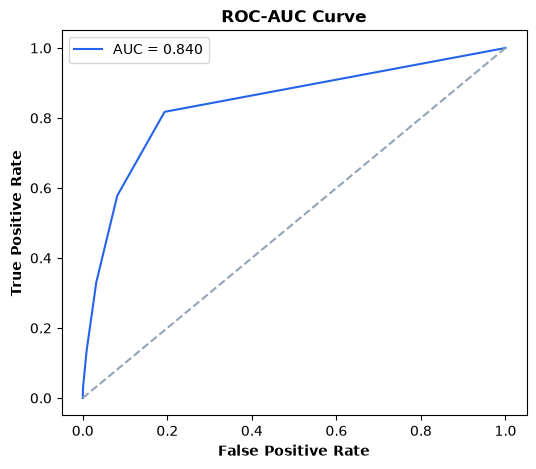

ROC-AUC Score: 0.8395550894735969


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_knn)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_knn)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')
plt.legend()
plt.show()

print("ROC-AUC Score:", auc_score)

#### KNN Precision-Recall Curve

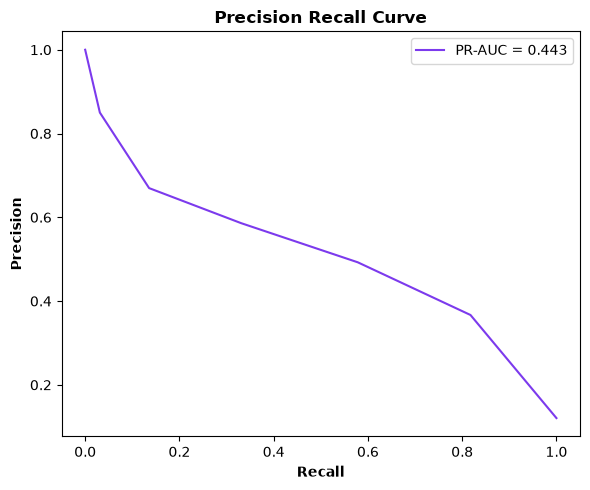

PR-AUC Score: 0.44253435515863815


In [87]:
from sklearn.metrics import  precision_recall_curve, average_precision_score

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_knn)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_knn)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, color='#7C3AED', label=f"PR-AUC = {pr_auc:.3f}")

plt.title("Precision Recall Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **Support Vector Machine (SVM)**

#### SVM Model Training

In [45]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

svc_model = CalibratedClassifierCV(
    SVC(random_state=42),
    method='sigmoid',
    cv=5,
    ensemble=False
)

svc_model.fit(X_train_scaled, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",SVC(random_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",False
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,[<sklearn.cali...0025A136F3CB0>]
"classes_ class

#### SVM Model Predictions

In [47]:
y_pred_svc = svc_model.predict(X_test_scaled)

#### SVM Model Evaluation

Accuracy Score: 0.9025765785690589


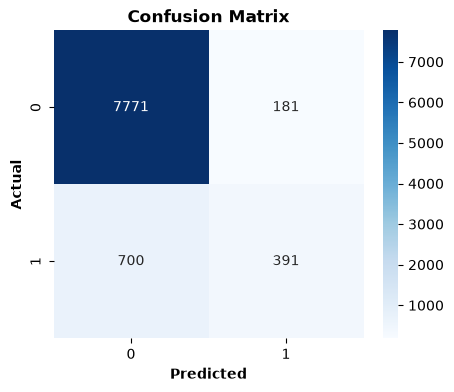


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7952
           1       0.68      0.36      0.47      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_svc = accuracy_score(y_test, y_pred_svc)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cr_svc = classification_report(y_test, y_pred_svc)

# Accuracy
print("Accuracy Score:", as_svc)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svc,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_svc)

#### SVM Log Loss Evaluation

In [55]:
from sklearn.metrics import log_loss

y_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

log_loss_svc = log_loss(y_test, y_proba_svc)

print("Log Loss:", log_loss_svc)

Log Loss: 0.2492919879198055


#### SVM ROC-AUC Curve

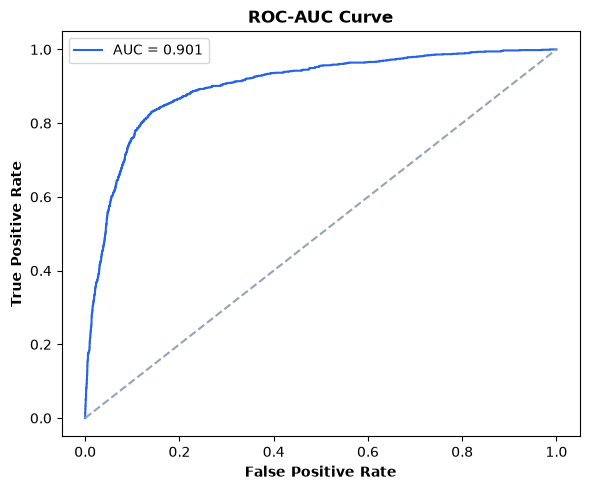

ROC-AUC Score: 0.9005453435553744


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_svc)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_svc)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1],[0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### SVM PR Curve

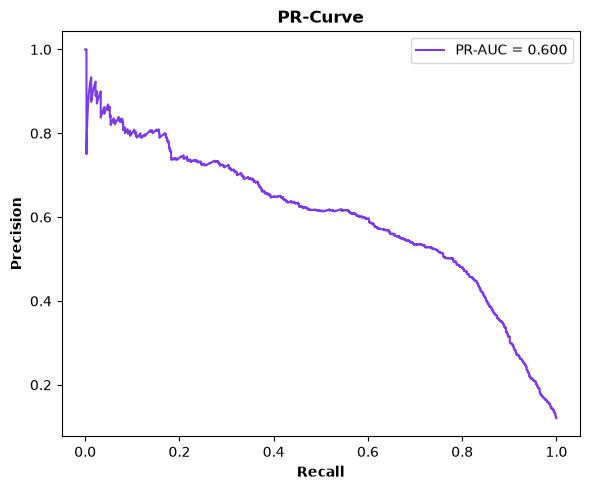

PR-AUC Score: 0.5996894863891197


In [88]:
from sklearn.metrics import  precision_recall_curve, average_precision_score

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_svc)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_svc)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, color='#7C3AED', label=f"PR-AUC = {pr_auc:.3f}")

plt.title("PR-Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **Haan, Gaussian Naive Bayes (GNB)**

#### Gaussian Naive Bayes Model Training

In [67]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[31970., 4198.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.88,0.12]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.001391
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](40,)","['age','balance','day',...,'poutcome_other','poutcome_success', 'poutcome_unknown']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,40
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 40)","[[ 40.79, 894.74, 15.9 ,..., 0.04, 0.01, 0.84], [ 41.45,1227.29, 15.22,..., 0.06, 0.18, 0.64]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 40)","[[ 100.58,1355269.79, 68.96,..., 0.04, 0.01, 0.14], [ 165.19,1563994.98, 71.69,..., 0.06, 0.15, 0.23]]"


#### GNB Model Predictions

In [69]:
y_pred_gnb = gnb_model.predict(X_test)

#### GNB Model Evaluation

Accuracy Score: 0.8638726086475728


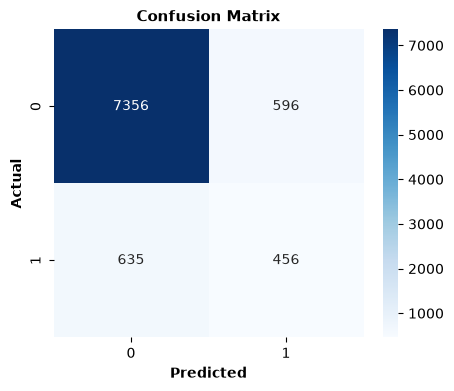


Classifiction Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92      7952
           1       0.43      0.42      0.43      1091

    accuracy                           0.86      9043
   macro avg       0.68      0.67      0.67      9043
weighted avg       0.86      0.86      0.86      9043



In [76]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gnb = accuracy_score(y_test, y_pred_gnb)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cr_gnb = classification_report(y_test, y_pred_gnb)

# Accuracy
print("Accuracy Score:", as_gnb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_gnb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassifiction Report:\n", cr_gnb)

#### GNB Log Loss Evaluation

In [80]:
from sklearn.metrics import log_loss

# Probability
y_proba_gnb = gnb_model.predict_proba(X_test)[:,1]

# Log loss
log_loss_gnb = log_loss(y_test, y_proba_gnb)

print("Log Loss:", log_loss_gnb)

Log Loss: 1.6535193135812072


#### GNB ROC-AUC Curve

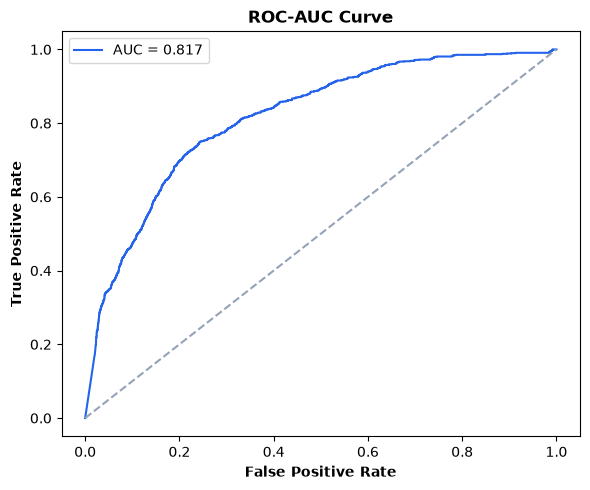

ROC-AUC Score: 0.8166753730448686


In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_gnb)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_gnb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1],[0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### GNB PR Curve

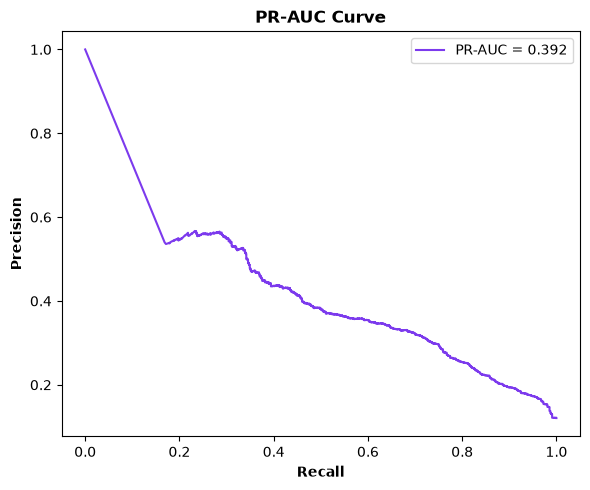

PR-AUC Score: 0.39218293306441476


In [94]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_gnb)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_gnb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')
 
plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **Decision Tree**

#### Decision Tree Model Training

In [97]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Decision Tree Predictions

In [99]:
y_pred_dt = dt_model.predict(X_test)

#### Decision Tree Evaluation

Accuracy Score: 0.8737144752847507


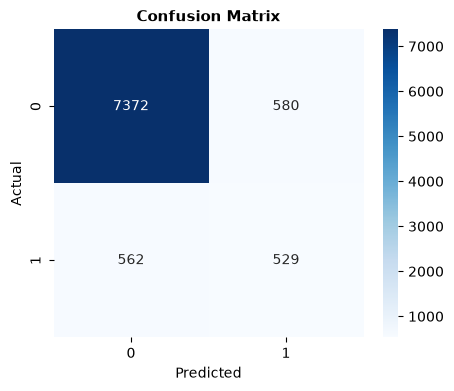


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.48      0.48      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.71      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [105]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cr_dt = classification_report(y_test, y_pred_dt)

# Accuracy
print("Accuracy Score:", as_dt)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_dt)

#### Decision Tree Log Loss Evaluation

In [108]:
from sklearn.metrics import log_loss

# Probability
y_proba_dt = dt_model.predict_proba(X_test)[:,1]

# Log loss
log_loss_dt = log_loss(y_test, y_proba_dt)

print("Log Loss:", log_loss_dt)

Log Loss: 4.551791680899235


#### Decision Tree ROC-AUC Curve

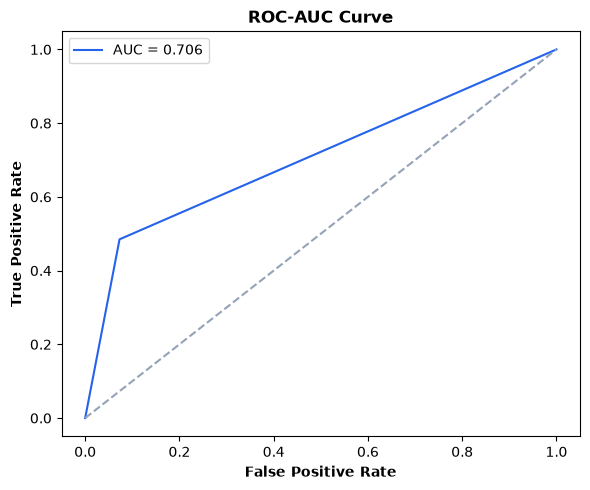

ROC-AUC Score: 0.7059693172785568


In [115]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC-Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)

# AUC-Score
auc_score = roc_auc_score(y_test, y_proba_dt)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### Decision Tree PR Curve

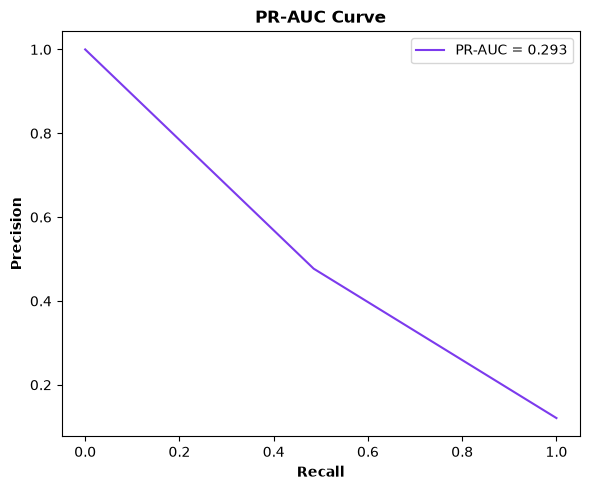

PR-AUC Score: 0.2934365541208964


In [119]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_dt)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_dt)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **Random Forest**

#### Random Forest Model Training

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Random Forest Predictions

In [124]:
y_pred_rf = rf_model.predict(X_test)

#### Random Forest Evaluation

Accuracy Score: 0.9018024991706293


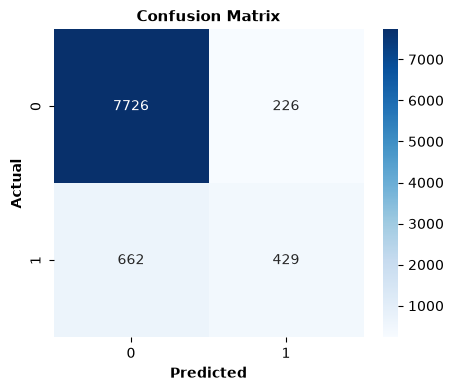


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.65      0.39      0.49      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [128]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf)

# Accuracy
print("Accuracy Score:", as_rf)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_rf)

#### Random Forest Log Loss Evaluation

In [131]:
from sklearn.metrics import log_loss

# Probability
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

# log loss
log_loss_rf = log_loss(y_test, y_proba_rf)
print("Log Loss:", log_loss_rf)

Log Loss: 0.24640623246299248


#### Random Forest ROC-AUC Curve

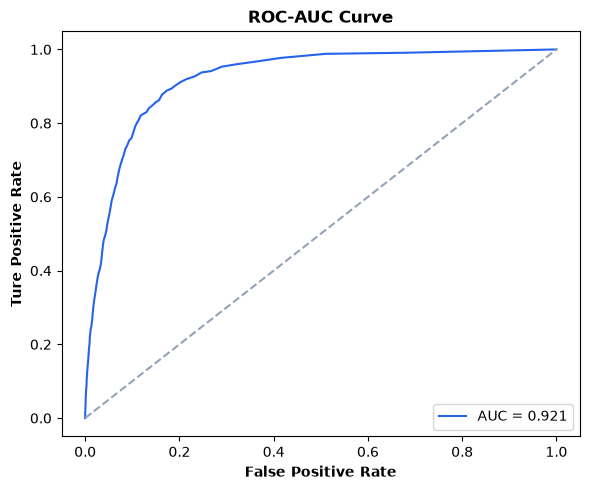

ROC-AUC Score: 0.9212039537868826


In [138]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("Ture Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### Random Forest PR Curve

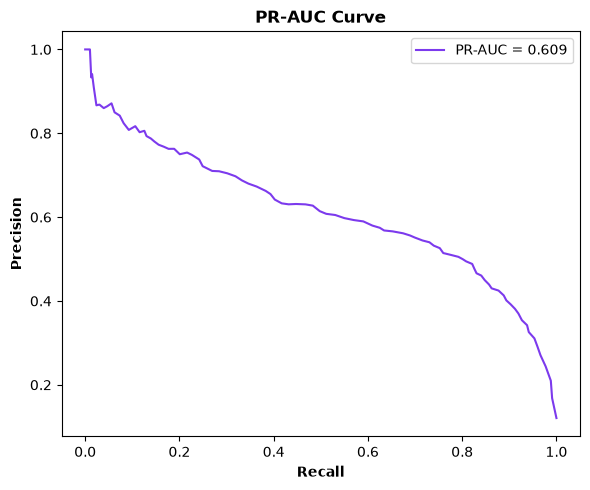

PR-AUC Score: 0.6090441487304822


In [139]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **Gradient Boosting**

#### Gradient Boosting Model Training

In [142]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

#### Gradient Boosting Predictions

In [144]:
y_pred_gb = gb_model.predict(X_test)

#### Gradient Boosting Evaluation

Accuracy Score: 0.9006966714585868


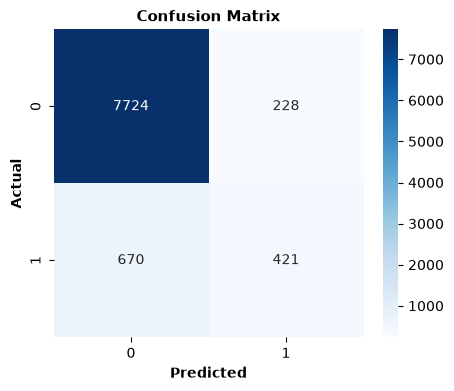


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.65      0.39      0.48      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043



In [149]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)
cr_gb = classification_report(y_test, y_pred_gb)

# Accuracy
print("Accuracy Score:", as_gb)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gb)

#### Gradient Boosting Log Loss Evaluation

In [153]:
from sklearn.metrics import log_loss

# Probability
y_proba_gb = gb_model.predict_proba(X_test)[:,1]

# log loss
log_loss_gb = log_loss(y_test, y_proba_gb)
print("log Loss:", log_loss_gb)

log Loss: 0.2187244877967197


#### Gradient Boosting ROC-AUC Curve

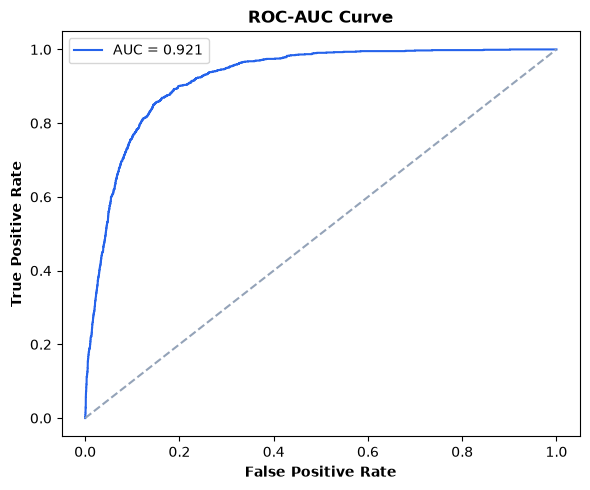

ROC-AUC Score: 0.9211630345777689


In [156]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC-Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_gb)

# AUC-Score
auc_score = roc_auc_score(y_test, y_proba_gb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1],[0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### Gradient Boosting PR Curve

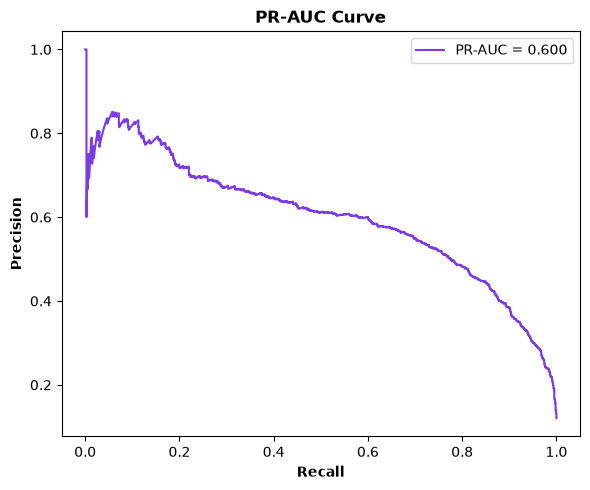

PR-AUC Score: 0.5999435801706972


In [159]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_gb)

# PR-AUC Score
pr_auc = average_precision_score(y_test, y_proba_gb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **XGBoost**

#### XGBoost Model Training

In [161]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### XGBoost Predictions

In [163]:
y_pred_xgb = xgb_model.predict(X_test)

#### XGBoost Evaluation

Accuracy Score: 0.9044564856795311


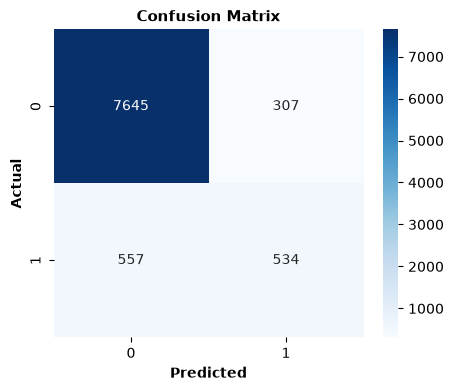


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7952
           1       0.63      0.49      0.55      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.73      0.75      9043
weighted avg       0.90      0.90      0.90      9043



In [166]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_xgb = accuracy_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cr_xgb = classification_report(y_test, y_pred_xgb)

# Accuracy
print("Accuracy Score:", as_xgb)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_xgb)

#### XGBoost Log Loss Evaluation

In [168]:
from sklearn.metrics import log_loss

# Probability
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

# Log loss
log_loss_xgb = log_loss(y_test, y_proba_xgb)
print("Logg Loss:", log_loss_xgb)

Logg Loss: 0.2120070457458496


#### XGBoost ROC-AUC Curve

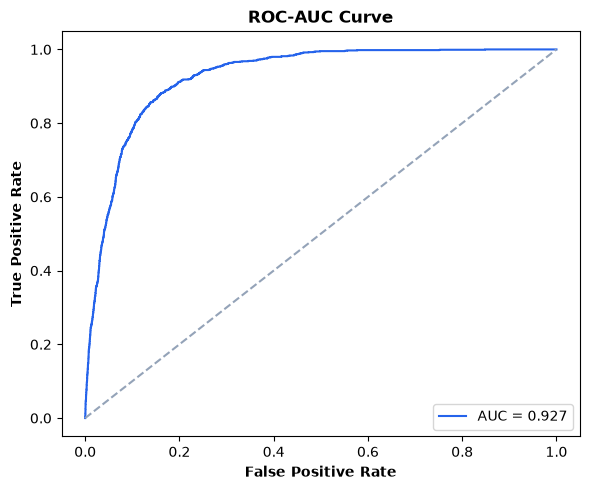

ROC-AUC Score: 0.9267707528396779


In [174]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)

# AUC-Score
auc_score = roc_auc_score(y_test, y_proba_xgb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### XGBoost PR Curve

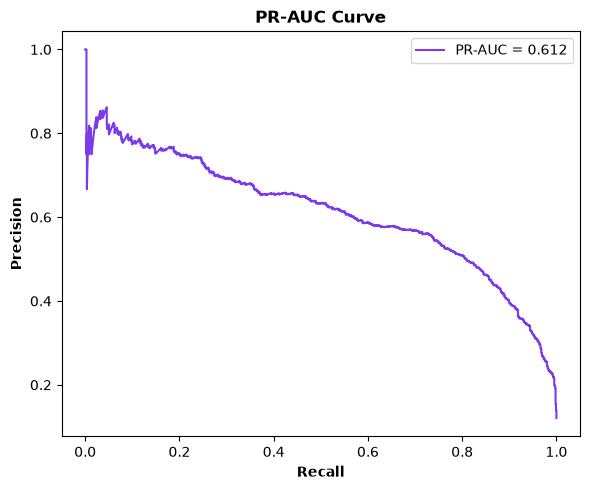

PR-AUC Score: 0.6122551967038745


In [177]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_xgb)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **LightGBM**

#### LightGBM Model Training

In [180]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


#### LightGBM Predictions

In [182]:
y_pred_lgbm = lgbm_model.predict(X_test)

#### LightGBM Evaluation

Accuracy Score: 0.9056728961627778


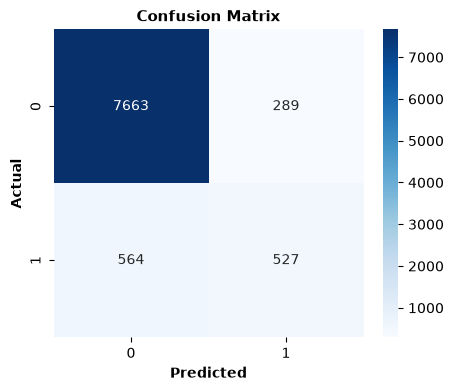


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7952
           1       0.65      0.48      0.55      1091

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



In [185]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lgbm = accuracy_score(y_test, y_pred_lgbm)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
cr_lgbm = classification_report(y_test, y_pred_lgbm)

# Accuracy
print("Accuracy Score:", as_lgbm)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lgbm)

#### LightGBM Log Loss Evaluation

In [188]:
from sklearn.metrics import log_loss

# Probability
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:,1]

# log loss
log_loss_lgbm = log_loss(y_test, y_proba_lgbm)
print("Log Loss:", log_loss_lgbm)

Log Loss: 0.20191929097823666


#### LightGBM ROC-AUC Curve

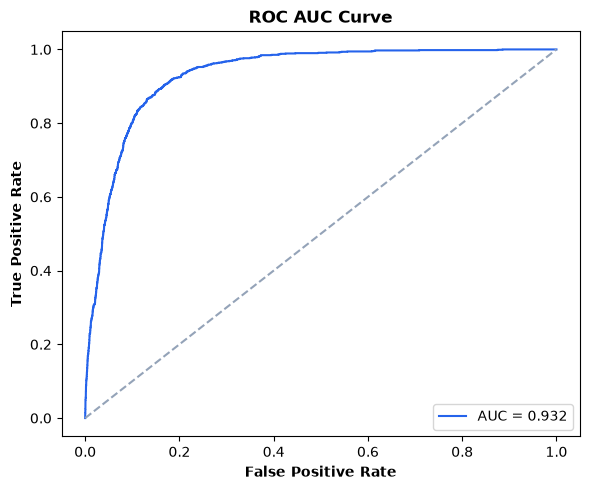

ROC-AUC Score: 0.9316741420106339


In [195]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lgbm)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_lgbm)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### LightGBM PR Curve

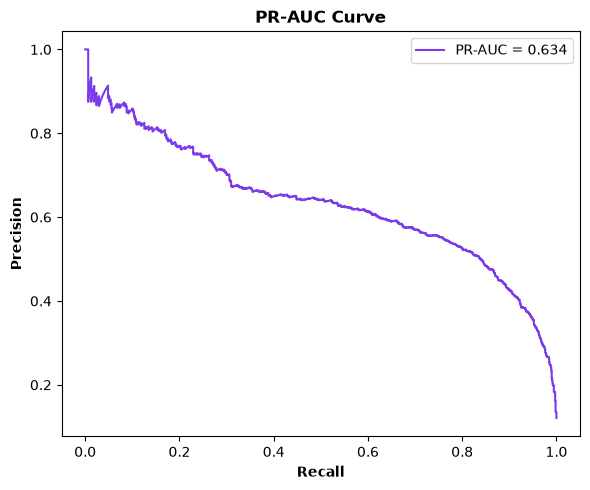

PR-AUC Score: 0.6335257234761017


In [199]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lgbm)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_lgbm)

# Plot
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

## **CatBoost**

#### CatBoost Model Training

In [201]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(random_state=42, verbose=0)
cb_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

#### CatBoost Predictions

In [204]:
y_pred_cb = cb_model.predict(X_test)

#### CatBoost Evaluation

Accuracy Score: 0.906668141103616


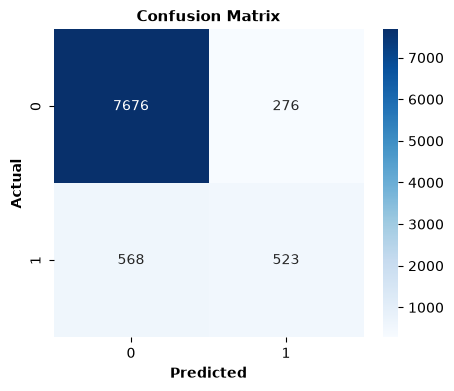


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.65      0.48      0.55      1091

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



In [206]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_cb = accuracy_score(y_test, y_pred_cb)
cm_cb = confusion_matrix(y_test, y_pred_cb)
cr_cb = classification_report(y_test, y_pred_cb)

# Accuracy
print("Accuracy Score:", as_cb)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_cb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_cb)

#### CatBoost Log Loss Evaluation

In [209]:
from sklearn.metrics import log_loss

# Probability
y_proba_cb = cb_model.predict_proba(X_test)[:,1]

# log loss
log_loss_cb = log_loss(y_test, y_proba_cb)
print("Log Loss:", log_loss_cb)

Log Loss: 0.2009361182257775


#### CatBoost ROC-AUC Curve

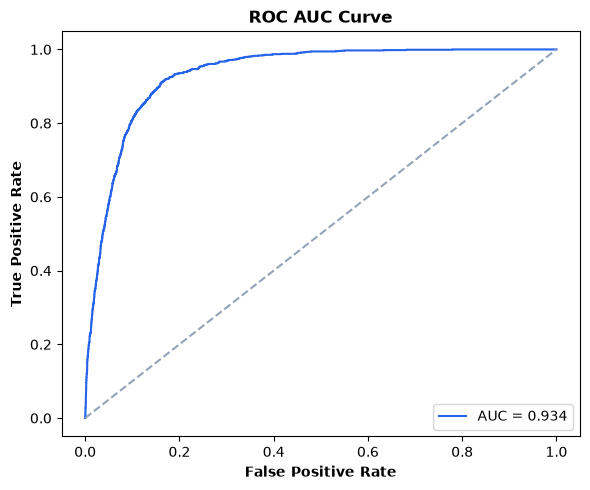

ROC-AUC Score: 0.9341141947929558


In [213]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_cb)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_cb)

# Plots
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### CatBoost PR Curve

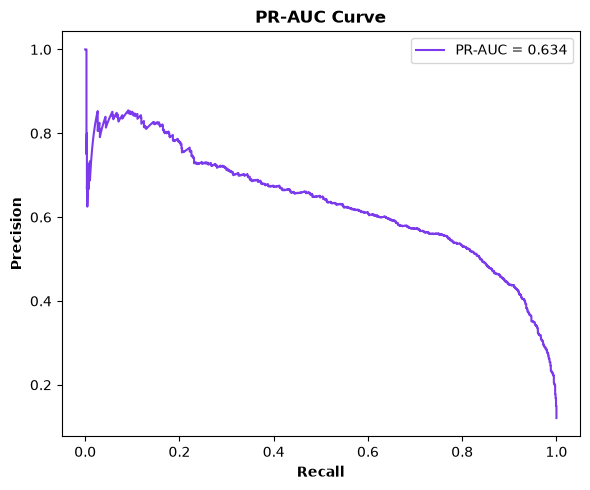

PR-AUC Score: 0.633612912640384


In [216]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_cb)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_cb)

# Plots
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

#

#### **Model Performance Comparison Table**

In [223]:
from sklearn.metrics import classification_report

cr_lr_dict = classification_report(y_test, y_pred_lr, output_dict=True)
cr_knn_dict = classification_report(y_test, y_pred_knn, output_dict=True)
cr_svc_dict = classification_report(y_test, y_pred_svc, output_dict=True)
cr_gnb_dict = classification_report(y_test, y_pred_gnb, output_dict=True)
cr_dt_dict = classification_report(y_test, y_pred_dt, output_dict=True)
cr_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
cr_gb_dict = classification_report(y_test, y_pred_gb, output_dict=True)
cr_xgb_dict = classification_report(y_test, y_pred_xgb, output_dict=True)
cr_lgbm_dict = classification_report(y_test, y_pred_lgbm, output_dict=True)
cr_cb_dict = classification_report(y_test, y_pred_cb, output_dict=True)

# Comparison
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVC",
        "GNB",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy": [
        as_lr,
        as_knn,
        as_svc,
        as_gnb,
        as_dt,
        as_rf,
        as_gb,
        as_xgb,
        as_lgbm,
        as_cb
    ],
    "Precision": [
        cr_lr_dict['weighted avg']['precision'],
        cr_knn_dict['weighted avg']['precision'],
        cr_svc_dict['weighted avg']['precision'],
        cr_gnb_dict['weighted avg']['precision'],
        cr_dt_dict['weighted avg']['precision'],
        cr_rf_dict['weighted avg']['precision'],
        cr_gb_dict['weighted avg']['precision'],
        cr_xgb_dict['weighted avg']['precision'],
        cr_lgbm_dict['weighted avg']['precision'],
        cr_cb_dict['weighted avg']['precision']
    ],
    "Recall": [
        cr_lr_dict['weighted avg']['recall'],
        cr_knn_dict['weighted avg']['recall'],
        cr_svc_dict['weighted avg']['recall'],
        cr_gnb_dict['weighted avg']['recall'],
        cr_dt_dict['weighted avg']['recall'],
        cr_rf_dict['weighted avg']['recall'],
        cr_gb_dict['weighted avg']['recall'],
        cr_xgb_dict['weighted avg']['recall'],
        cr_lgbm_dict['weighted avg']['recall'],
        cr_cb_dict['weighted avg']['recall']
    ],
    "F1-Score": [
        cr_lr_dict['weighted avg']['f1-score'],
        cr_knn_dict['weighted avg']['f1-score'],
        cr_svc_dict['weighted avg']['f1-score'],
        cr_gnb_dict['weighted avg']['f1-score'],
        cr_dt_dict['weighted avg']['f1-score'],
        cr_rf_dict['weighted avg']['f1-score'],
        cr_gb_dict['weighted avg']['f1-score'],
        cr_xgb_dict['weighted avg']['f1-score'],
        cr_lgbm_dict['weighted avg']['f1-score'],
        cr_cb_dict['weighted avg']['f1-score']
    ],
    "Log Loss": [
        log_loss_lr,
        log_loss_knn,
        log_loss_svc,
        log_loss_gnb,
        log_loss_dt,
        log_loss_rf,
        log_loss_gb,
        log_loss_xgb,
        log_loss_lgbm,
        log_loss_cb
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_knn),
        roc_auc_score(y_test, y_proba_svc),
        roc_auc_score(y_test, y_proba_gnb),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_lgbm),
        roc_auc_score(y_test, y_proba_cb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_knn),
        average_precision_score(y_test, y_proba_svc),
        average_precision_score(y_test, y_proba_gnb),
        average_precision_score(y_test, y_proba_dt),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_gb),
        average_precision_score(y_test, y_proba_xgb),
        average_precision_score(y_test, y_proba_lgbm),
        average_precision_score(y_test, y_proba_cb)
    ]
})

comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False).round(4).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Log Loss,ROC-AUC,PR-AUC
0,CatBoost,0.9067,0.8977,0.9067,0.9003,0.2009,0.9341,0.6336
1,LightGBM,0.9057,0.8970,0.9057,0.8997,0.2019,0.9317,0.6335
2,XGBoost,0.9045,0.8962,0.9045,0.8990,0.2120,0.9268,0.6123
3,Random Forest,0.9018,0.8890,0.9018,0.8909,0.2464,0.9212,0.6090
4,Gradient Boosting,0.9007,0.8874,0.9007,0.8894,0.2187,0.9212,0.5999
5,Logistic Regression,0.8972,0.8816,0.8972,0.8831,0.2361,0.9048,0.5645
6,SVC,0.9026,0.8892,0.9026,0.8889,0.2493,0.9005,0.5997
7,KNN,0.8911,0.8739,0.8911,0.8775,0.9804,0.8396,0.4425
8,GNB,0.8639,0.8618,0.8639,0.8628,1.6535,0.8167,0.3922
9,Decision Tree,0.8737,0.8746,0.8737,0.8742,4.5518,0.7060,0.2934


#### Model Performance Comparison Visualization

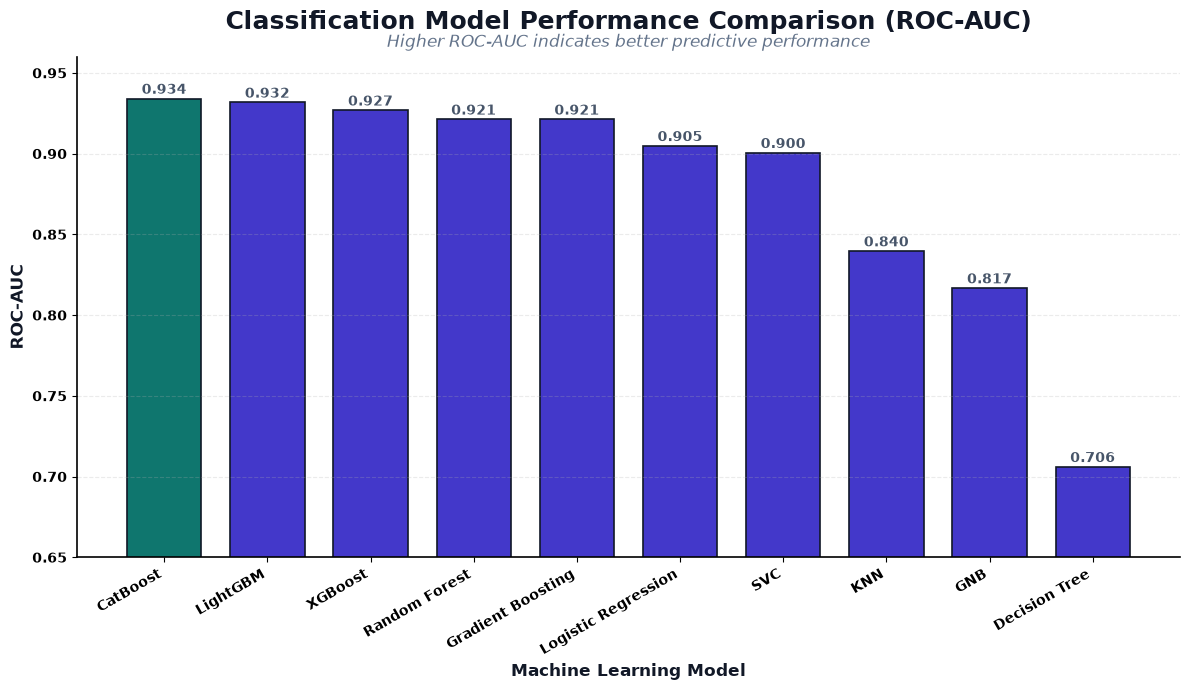

In [391]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

colors = ['#4338CA'] * len(comparison_df)

# Highest best model
best_index = comparison_df['ROC-AUC'].idxmax()
best_position = comparison_df.index.get_loc(best_index)

colors[best_position] = '#0F766E'

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"],
    color=colors,
    edgecolor='#111827',
    linewidth=1.2,
    width=0.72
)

plt.title(
    "Classification Model Performance Comparison (ROC-AUC)",
    fontsize=18,
    fontweight='bold',
    color='#111827',
    pad=20
)

plt.text(
    0.5, 1.02,
    "Higher ROC-AUC indicates better predictive performance",
    transform = plt.gca().transAxes,
    ha='center',
    fontsize=12,
    color='#64748B',
    style='italic'
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=12,
    fontweight='bold',
    color='#111827'
)

plt.ylabel(
    "ROC-AUC",
    fontsize=12,
    fontweight='bold',
    color='#111827'
)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.xticks(
    rotation=30,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

plt.yticks(fontsize=10, fontweight='bold')

# Remove top/right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Top value

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#475569'
    )


plt.ylim(0.65, 0.96)

plt.tight_layout()
plt.show()

#

#### **CatBoost Hyperparameter Tuning**

In [295]:
from sklearn.model_selection import RandomizedSearchCV

cb = CatBoostClassifier(random_state=42, verbose=0)

param_dist = {
    'iterations': [100, 200, 300, 500, 700, 1000],
    'learning_rate':[0.001, 0.003, 0.005, 0.01, 0.03, 0.05],
    'depth':[2, 3, 5, 7, 10, 13],
    'l2_leaf_reg': [3, 6, 7, 11, 15],
    'border_count': [32, 64, 128, 220],
    'random_strength': [0.3, 0.5, 1, 3, 5, 9],
    'bagging_temperature':[0.5, 1, 3, 5],
    'subsample': [0.50, 0.60, 0.70, 0.80, 0.90, 1.0],
    'colsample_bylevel': [0.6, 0.7, 0.8, 0.9, 1.0],
    'auto_class_weights': ['Balanced', 'SqrtBalanced']
}

random_search_cb = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    cv=5,
    n_iter=20,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search_cb.fit(X_train, y_train)

print("Best Parameters:", random_search_cb.best_params_)
print("Best Score:", random_search_cb.best_score_)

Best Parameters: {'subsample': 1.0, 'random_strength': 0.3, 'learning_rate': 0.05, 'l2_leaf_reg': 15, 'iterations': 700, 'depth': 5, 'colsample_bylevel': 0.8, 'border_count': 220, 'bagging_temperature': 3, 'auto_class_weights': 'Balanced'}
Best Score: 0.9346082007202003


#### Tuned CatBoost Model Training

In [296]:
cb_tuned = CatBoostClassifier(
    subsample=1.0,
    random_strength=0.3,
    learning_rate=0.05,
    l2_leaf_reg=15,
    iterations=700,
    depth=5,
    colsample_bylevel=0.8,
    border_count=220,
    bagging_temperature=3,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0
)

cb_tuned.fit(X_train, y_train)

CatBoostClassifier(auto_class_weights='Balanced', bagging_temperature=3, border_count=220, colsample_bylevel=0.8, depth=5, iterations=700, l2_leaf_reg=15, learning_rate=0.05, random_state=42, random_strength=0.3, subsample=1.0, verbose=0)

#### Tuned CatBoost Test Predictions

In [297]:
y_pred_cb_tuned = cb_tuned.predict(X_test)

#### Tuned CatBoost Model Evaluation

Accuracy Score: 0.8609974565962623


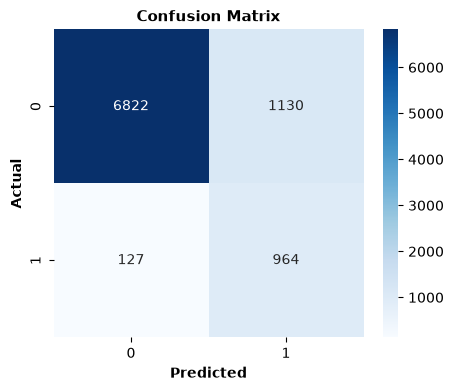


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.86      0.92      7952
           1       0.46      0.88      0.61      1091

    accuracy                           0.86      9043
   macro avg       0.72      0.87      0.76      9043
weighted avg       0.92      0.86      0.88      9043



In [299]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_cb_tuned = accuracy_score(y_test, y_pred_cb_tuned)
cm_cb_tuned = confusion_matrix(y_test, y_pred_cb_tuned)
cr_cb_tuned = classification_report(y_test, y_pred_cb_tuned)

# Accuracy
print("Accuracy Score:", as_cb_tuned)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_cb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_cb_tuned)

#### Log Loss Evaluation

In [302]:
from sklearn.metrics import log_loss

# Probability
y_proba_cb_tuned = cb_tuned.predict_proba(X_test)[:,1]

# log loss
log_loss_cb_tuned = log_loss(y_test, y_proba_cb_tuned)
print("Log Loss:", log_loss_cb_tuned)

Log Loss: 0.3173378051844567


#### ROC-AUC Curve Analysis

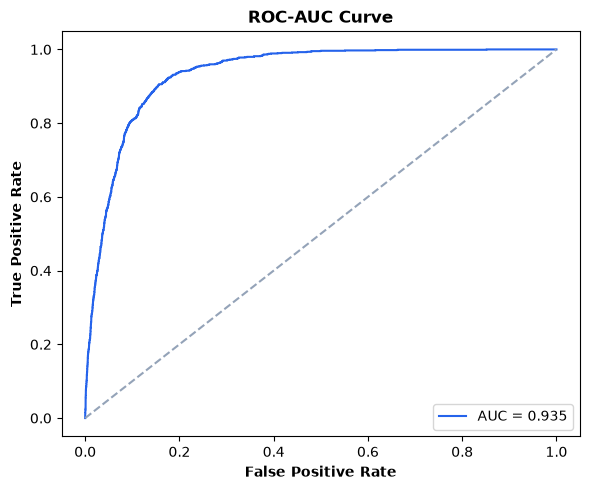

ROC-AUC Score: 0.9349798377801181


In [305]:
from sklearn.metrics import roc_curve, roc_auc_score

# roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_cb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_cb_tuned)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### PR-AUC Curve Analysis

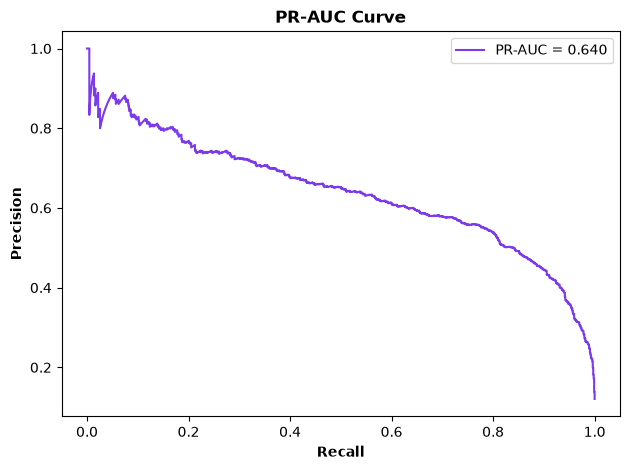

PR-AUC Score: 0.6397168097228628


In [308]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_cb_tuned)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_cb_tuned)

# Plot
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

#### LightGBM Hyperparameter Tuning

In [309]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier(random_state=42, verbose=-1)

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.001, 0.003, 0.005, 0.01, 0.03],
    'num_leaves': [15, 31, 50, 65, 85],
    'max_depth': [3, 5, 7, 9, 12],
    'min_child_samples': [10, 20, 30, 50, 60],
    'subsample': [0.60, 0.70, 0.80, 0.90, 1.0],
    'colsample_bytree': [0.60, 0.70, 0.80, 0.90, 1.0],
    'reg_alpha': [0, 0.01, 0.05, 1, 3],
    'reg_lambda': [0, 0.1, 0.5, 2, 5, 10],
    'min_split_gain': [0, 0.001, 0.005, 0.1, 0.5, 1],
    'class_weight': [None, 'balanced'],
    'max_bin': [63, 127, 255, 322]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    cv=5,
    n_iter=20,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

print("Best Parameters:", random_search_lgbm.best_params_)
print("Best Score:", random_search_lgbm.best_score_)

Best Parameters: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.05, 'num_leaves': 50, 'n_estimators': 700, 'min_split_gain': 0, 'min_child_samples': 30, 'max_depth': 9, 'max_bin': 127, 'learning_rate': 0.01, 'colsample_bytree': 0.6, 'class_weight': 'balanced'}
Best Score: 0.9329804294912739


#### Tuned LightGBM Model Training

In [310]:
lgbm_tuned = LGBMClassifier(
    subsample=0.9,
    reg_lambda=5,
    reg_alpha=0.05,
    num_leaves=50,
    n_estimators=700,
    min_split_gain=0,
    min_child_samples=30,
    max_depth=9,
    max_bin=127,
    learning_rate=0.01,
    colsample_bytree=0.6,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgbm_tuned.fit(X_train, y_train)

,num_leaves,50
,max_depth,9
,learning_rate,0.01
,n_estimators,700
,class_weight,'balanced'
,min_child_samples,30
,subsample,0.9
,colsample_bytree,0.6
,reg_alpha,0.05
,reg_lambda,5
,random_state,42


#### Tuned LightGBM Test Predictions

In [312]:
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

#### Tuned LightGBM Model Evaluation

Accuracy Score: 0.8527037487559438


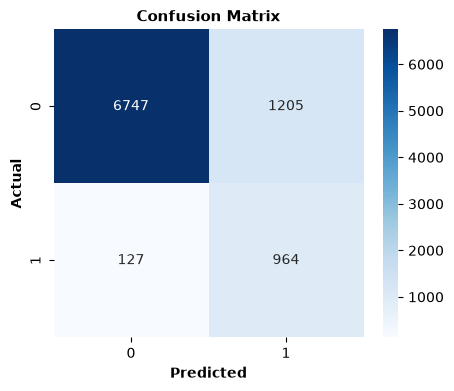


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      7952
           1       0.44      0.88      0.59      1091

    accuracy                           0.85      9043
   macro avg       0.71      0.87      0.75      9043
weighted avg       0.92      0.85      0.87      9043



In [314]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lgbm_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)
cm_lgbm_tuned = confusion_matrix(y_test, y_pred_lgbm_tuned)
cr_lgbm_tuned = classification_report(y_test, y_pred_lgbm_tuned)

# Accuracy
print("Accuracy Score:", as_lgbm_tuned)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_lgbm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lgbm_tuned)

#### Log Loss Evaluation

In [317]:
from sklearn.metrics import log_loss

# Probability
y_proba_lgbm_tuned = lgbm_tuned.predict_proba(X_test)[:,1]

# log loss
log_loss_lgbm_tuned = log_loss(y_test, y_proba_lgbm_tuned)
print("Log Loss:", log_loss_lgbm_tuned)

Log Loss: 0.3258892623169145


#### ROC-AUC Curve Analysis — Tuned LightGBM

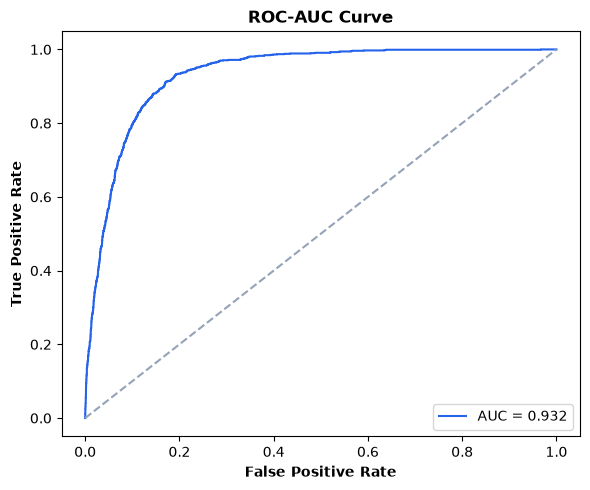

ROC-AUC Score: 0.9322149671631991


In [319]:
from sklearn.metrics import roc_curve, roc_auc_score

# roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lgbm_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_lgbm_tuned)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### PR-AUC Curve Analysis — Tuned LightGBM

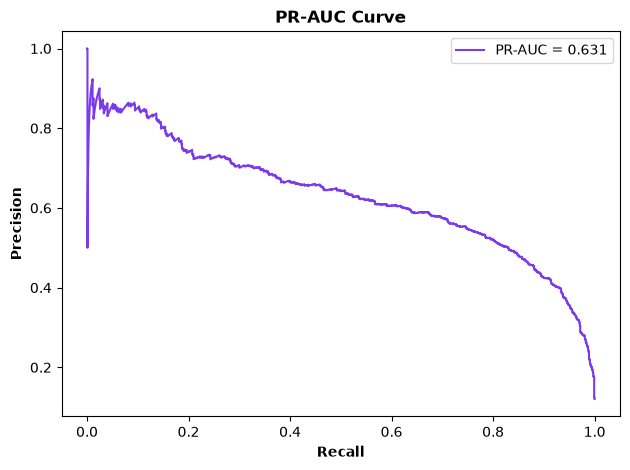

PR-AUC Score: 0.6305535327378167


In [321]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lgbm_tuned)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_lgbm_tuned)

# Plot
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

##

#### XGBoost Hyperparameter Tuning

In [322]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.001, 0.003, 0.005, 0.01, 0.05, 0.1, 0.3],
    'max_depth': [2, 3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.60, 0.80, 0.90, 1.0],
    'colsample_bytree': [0.50, 0.60, 0.80, 1.0],
    'gamma': [0, 0.01, 0.05, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.001, 0.005, 0.1, 0.5, 1, 3],
    'reg_lambda': [1, 3, 5, 10, 15],
    'scale_pos_weight': [1, 2, 3, 5, 7],
    'eval_metric': ['logloss', 'auc'],
    'objective': ["binary:logistic"]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    cv=5,
    n_iter=20,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print("Best Score:", random_search_xgb.best_score_)

Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 7, 'reg_lambda': 15, 'reg_alpha': 0, 'objective': 'binary:logistic', 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1, 'eval_metric': 'auc', 'colsample_bytree': 0.8}
Best Score: 0.9325836235267813


#### Tuned XGBoost Model Training

In [323]:
xgb_tuned = XGBClassifier(
    subsample=0.9,
    scale_pos_weight=7,
    reg_lambda=15,
    reg_alpha=0,
    objective='binary:logistic',
    n_estimators=300,
    min_child_weight=5,
    max_depth=5,
    learning_rate=0.1,
    gamma=1,
    eval_metric='auc',
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### Tuned XGBoost Test Predictions

In [324]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

#### Tuned XGBoost Classification Performance

Accuracy Score: 0.8659736813004534


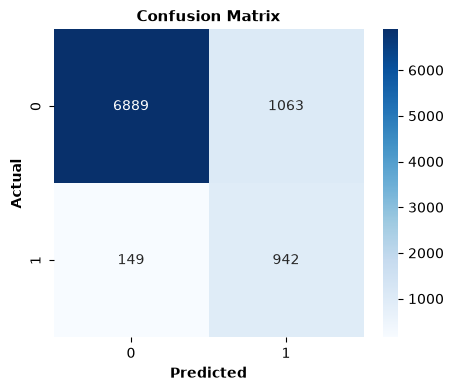


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92      7952
           1       0.47      0.86      0.61      1091

    accuracy                           0.87      9043
   macro avg       0.72      0.86      0.76      9043
weighted avg       0.92      0.87      0.88      9043



In [326]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
cr_xgb_tuned = classification_report(y_test, y_pred_xgb_tuned)

# Accuracy
print("Accuracy Score:", as_xgb_tuned)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_xgb_tuned)

#### Log Loss Evaluation — Tuned XGBoost

In [328]:
from sklearn.metrics import log_loss

# Probability
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test)[:,1]

# log loss
log_loss_xgb_tuned = log_loss(y_test, y_proba_xgb_tuned)
print("Log Loss:", log_loss_xgb_tuned)

Log Loss: 0.29839324951171875


#### ROC-AUC Curve Analysis — Tuned XGBoost

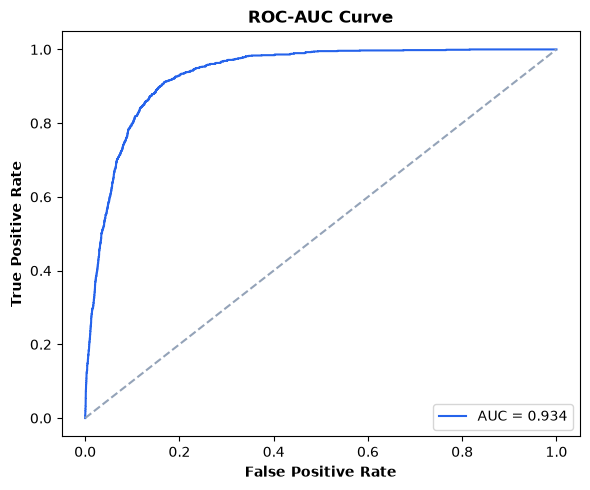

ROC-AUC Score: 0.9337703005383355


In [330]:
from sklearn.metrics import roc_curve, roc_auc_score

# roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_proba_xgb_tuned)

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color='#2563EB')
plt.plot([0,1], [0,1], linestyle='--', color='#94A3B8')

plt.title("ROC-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate", fontweight='bold')
plt.ylabel("True Positive Rate", fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)

#### PR-AUC Curve Analysis — Tuned XGBoost

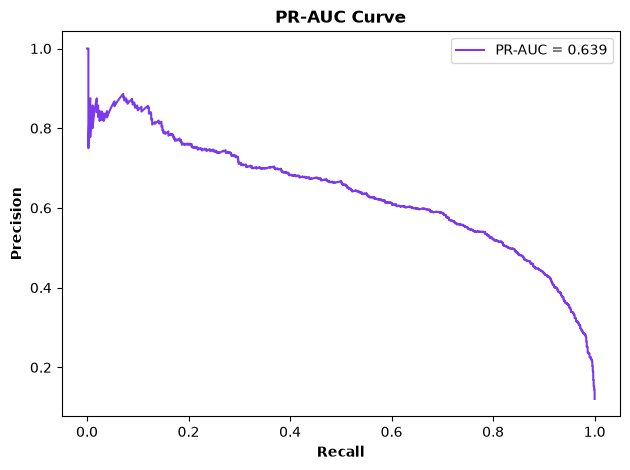

PR-AUC Score: 0.6385106995796054


In [332]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb_tuned)

# PR AUC
pr_auc = average_precision_score(y_test, y_proba_xgb_tuned)

# Plot
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color='#7C3AED')

plt.title("PR-AUC Curve", fontsize=12, fontweight='bold')
plt.xlabel("Recall", fontweight='bold')
plt.ylabel("Precision", fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

print("PR-AUC Score:", pr_auc)

#

### **Model Performance Comparison - Original vs Tuned Models**

In [385]:
from sklearn.metrics import classification_report

cr_cb_tuned_dict = classification_report(y_test, y_pred_cb_tuned, output_dict=True)
cr_cb_dict = classification_report(y_test, y_pred_cb, output_dict=True)
cr_lgbm_tuned_dict = classification_report(y_test, y_pred_lgbm_tuned, output_dict=True)
cr_lgbm_dict = classification_report(y_test, y_pred_lgbm, output_dict=True)
cr_xgb_tuned_dict = classification_report(y_test, y_pred_xgb_tuned, output_dict=True)
cr_xgb_dict = classification_report(y_test, y_pred_xgb, output_dict=True)

comparison_tuned_df = pd.DataFrame({
    "Model": [
        'CatBoost Tuned',
        'CatBoost Original',
        'LightGBM Tuned',
        'lightGBM Original',
        'XGBoost Tuned',
        'XGBoost Original'
    ],
    "Accuracy": [
        as_cb_tuned,
        as_cb,
        as_lgbm_tuned,
        as_lgbm,
        as_xgb_tuned,
        as_xgb
    ],
    "Precision": [
        cr_cb_tuned_dict['weighted avg']['precision'],
        cr_cb_dict['weighted avg']['precision'],
        cr_lgbm_tuned_dict['weighted avg']['precision'],
        cr_lgbm_dict['weighted avg']['precision'],
        cr_xgb_tuned_dict['weighted avg']['precision'],
        cr_xgb_dict['weighted avg']['precision']
    ],
    "Recall": [
        cr_cb_tuned_dict['weighted avg']['recall'],
        cr_cb_dict['weighted avg']['recall'],
        cr_lgbm_tuned_dict['weighted avg']['recall'],
        cr_lgbm_dict['weighted avg']['recall'],
        cr_xgb_tuned_dict['weighted avg']['recall'],
        cr_xgb_dict['weighted avg']['recall']
    ],
    "F1-Score": [
        cr_cb_tuned_dict['weighted avg']['f1-score'],
        cr_cb_dict['weighted avg']['f1-score'],
        cr_lgbm_tuned_dict['weighted avg']['f1-score'],
        cr_lgbm_dict['weighted avg']['f1-score'],
        cr_xgb_tuned_dict['weighted avg']['f1-score'],
        cr_xgb_dict['weighted avg']['f1-score']
    ],
    "Log Loss": [
        log_loss_cb_tuned,
        log_loss_cb,
        log_loss_lgbm_tuned,
        log_loss_lgbm,
        log_loss_xgb_tuned,
        log_loss_xgb
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_cb_tuned),
        roc_auc_score(y_test, y_proba_cb),
        roc_auc_score(y_test, y_proba_lgbm_tuned),
        roc_auc_score(y_test, y_proba_lgbm),
        roc_auc_score(y_test, y_proba_xgb_tuned),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba_cb_tuned),
        average_precision_score(y_test, y_proba_cb),
        average_precision_score(y_test, y_proba_lgbm_tuned),
        average_precision_score(y_test, y_proba_lgbm),
        average_precision_score(y_test, y_proba_xgb_tuned),
        average_precision_score(y_test, y_proba_xgb)
    ]
})

comparison_tuned_df = comparison_tuned_df.sort_values(by='ROC-AUC', ascending=False).round(4).reset_index(drop=True)
comparison_tuned_df

,Model,Accuracy,Precision,Recall,F1-Score,Log Loss,ROC-AUC,PR-AUC
0,CatBoost Tuned,0.8610,0.9188,0.8610,0.8782,0.3173,0.9350,0.6397
1,CatBoost Original,0.9067,0.8977,0.9067,0.9003,0.2009,0.9341,0.6336
2,XGBoost Tuned,0.8660,0.9174,0.8660,0.8817,0.2984,0.9338,0.6385
3,LightGBM Tuned,0.8527,0.9167,0.8527,0.8717,0.3259,0.9322,0.6306
4,lightGBM Original,0.9057,0.8970,0.9057,0.8997,0.2019,0.9317,0.6335
5,XGBoost Original,0.9045,0.8962,0.9045,0.8990,0.2120,0.9268,0.6123


#### **Original vs Tuned Model Performance Visualization**

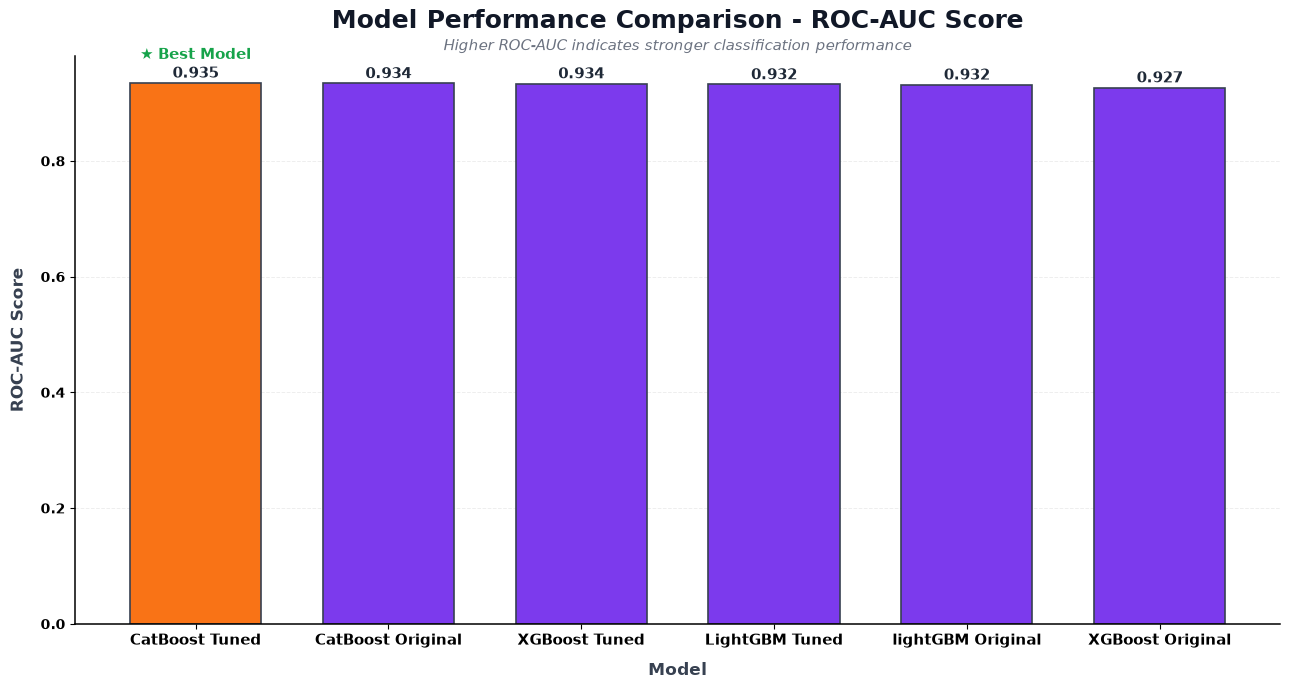

In [394]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 7))

colors = ['#7C3AED'] * len(comparison_tuned_df)

best_index = comparison_tuned_df['ROC-AUC'].idxmax()
best_position = comparison_tuned_df.index.get_loc(best_index)

colors[best_position] = '#F97316'

bars = plt.bar(
    comparison_tuned_df['Model'],
    comparison_tuned_df['ROC-AUC'],
    color=colors,
    edgecolor='#374151',
    linewidth=1.2,
    width=0.68
)

# Title
plt.title(
    "Model Performance Comparison - ROC-AUC Score",
    fontsize=18,
    fontweight='bold',
    color='#111827',
    pad=20
)

# Subtitle
plt.text(
    0.5, 1.01,
    "Higher ROC-AUC indicates stronger classification performance",
    ha='center',
    transform=plt.gca().transAxes,
    fontsize=11,
    color='#6B7280',
    style='italic'
)

# Axis labels
plt.xlabel(
    "Model",
    fontsize=12,
    fontweight='bold',
    color='#374151',
    labelpad=10
)

plt.ylabel(
    "ROC-AUC Score",
    fontsize=12,
    fontweight='bold',
    color='#374151',
    labelpad=10
)

# Tick labels
plt.xticks(
    fontsize=10.5,
    fontweight='bold'
)

plt.yticks(
    fontsize=10,
    fontweight='bold'
)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.22,
    linewidth=0.7
)

ax = plt.gca()
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=10.5,
        fontweight='bold',
        color='#1F2937'
    )

# Highlight best model
best_bar = bars[best_position]

plt.text(
    best_bar.get_x() + best_bar.get_width() / 2,
    best_bar.get_height() + 0.035,
    "★ Best Model",
    ha='center',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    color='#16A34A'
)

plt.tight_layout()
plt.show()

### **Final Model Performance Summary**

In [399]:
final_model_df = pd.DataFrame({
    "Model": ["CatBoost Tuned"],
    "Accuracy": [as_cb_tuned],
    "Precision": [cr_cb_tuned_dict["weighted avg"]["precision"]],
    "Recall": [cr_cb_tuned_dict["weighted avg"]["recall"]],
    "F1-Score": [cr_cb_tuned_dict["weighted avg"]["f1-score"]],
    "Log Loss": [log_loss_cb_tuned],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_cb_tuned)],
    "PR-AUC": [average_precision_score(y_test, y_proba_cb_tuned)]
})

final_model_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,Log Loss,ROC-AUC,PR-AUC
0,CatBoost Tuned,0.861,0.9188,0.861,0.8782,0.3173,0.935,0.6397


##

#### Final Model Training and Testing Performance

In [401]:
print("Train Score:", cb_tuned.score(X_train, y_train))
print("Test Score:", cb_tuned.score(X_test, y_test))

Train Score: 0.8704656049546561
Test Score: 0.8609974565962623


###### The small difference between the training and test scores indicates that the model generalizes well to unseen data, with no significant sign of overfitting.

###

#### Top 10 Feature Importance Analysis

In [410]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cb_tuned.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10).reset_index(drop=True)
feature_importance_df

,Feature,Importance
0,duration,30.014453
1,contact_unknown,9.764939
2,day,8.833413
3,poutcome_success,5.591781
4,month_may,4.304850
5,housing_yes,4.004956
6,age,3.964837
7,balance,3.754881
8,poutcome_unknown,3.398896
9,month_jul,3.186803


#### Top 10 Feature Importance Analysis

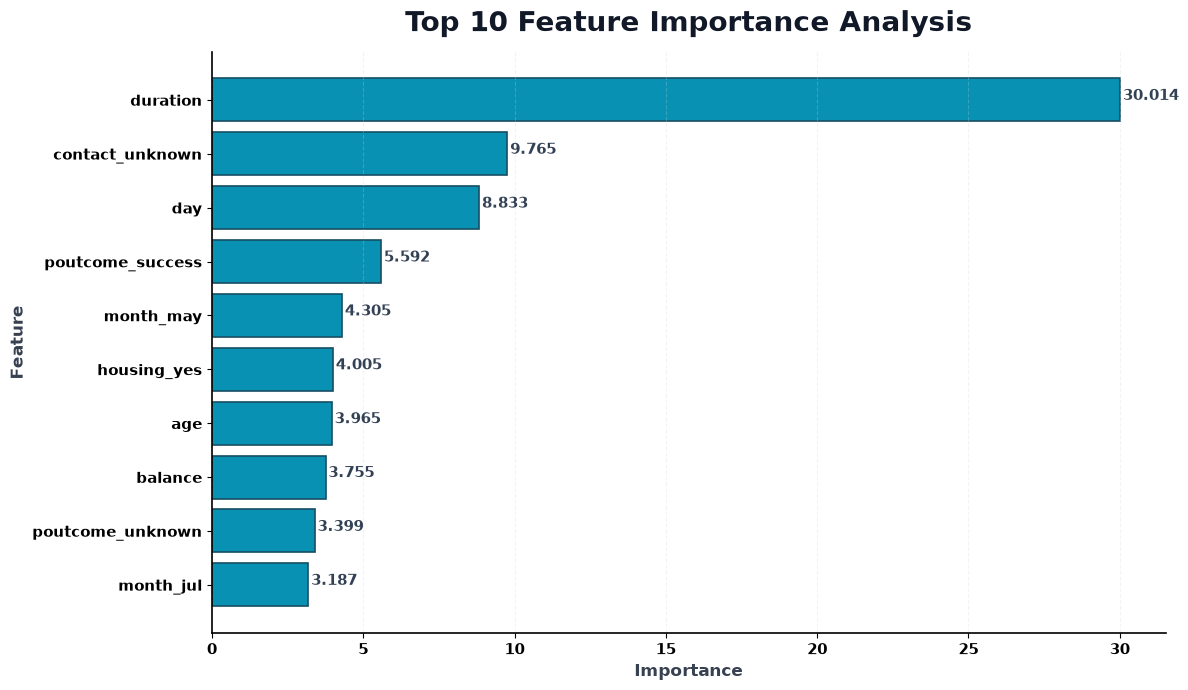

In [446]:
import matplotlib.pyplot as plt

top_10 = feature_importance_df.sort_values(by='Importance', ascending=True).head(10)

plt.figure(figsize=(12,7))

bars = plt.barh(
    top_10["Feature"],
    top_10["Importance"],
    color='#0891B2',
    linewidth=1.2,
    edgecolor='#164E63'
)

plt.title(
    "Top 10 Feature Importance Analysis",
    fontsize=20,
    fontweight='bold',
    color='#111827',
    pad=15
)

plt.xlabel(
    "Importance",
    fontsize=12,
    fontweight='bold',
    color='#374151'
)

plt.ylabel(
    "Feature",
    fontsize=12,
    fontweight='bold',
    color='#374151'
)

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25,
    color='#CBD5E1'
)

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

# Remove top\right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)


# Value
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.09,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        color='#334155',
        fontweight='bold',
        fontsize=11
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis for Model Interpretability

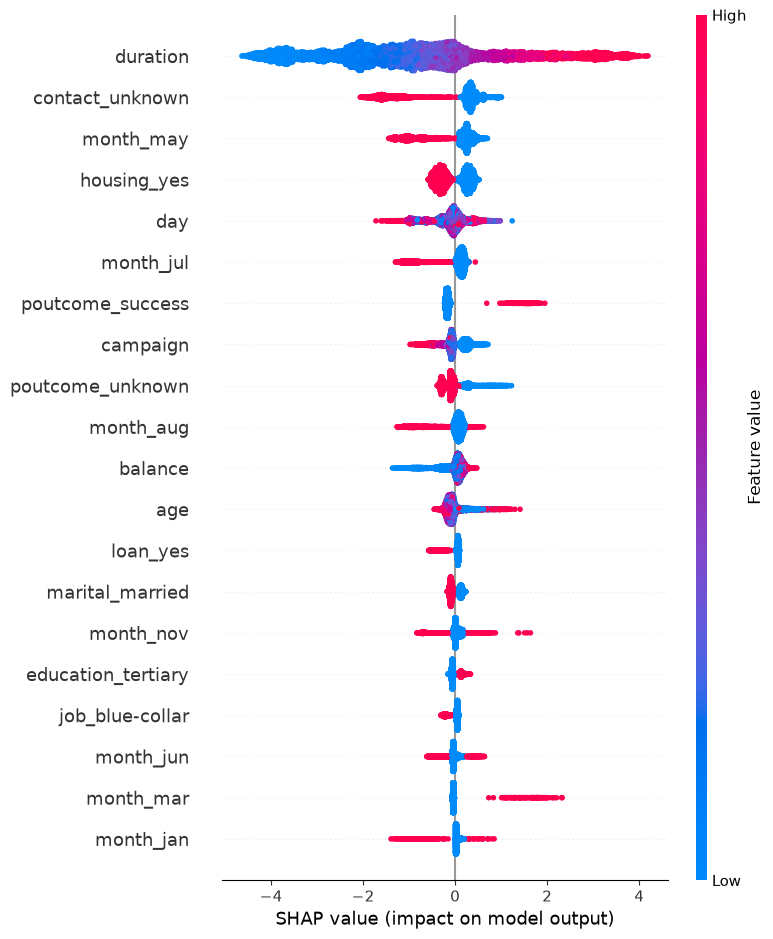

In [448]:
import shap

explainer = shap.TreeExplainer(cb_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

#### SHAP Dependence Analysis for Duration

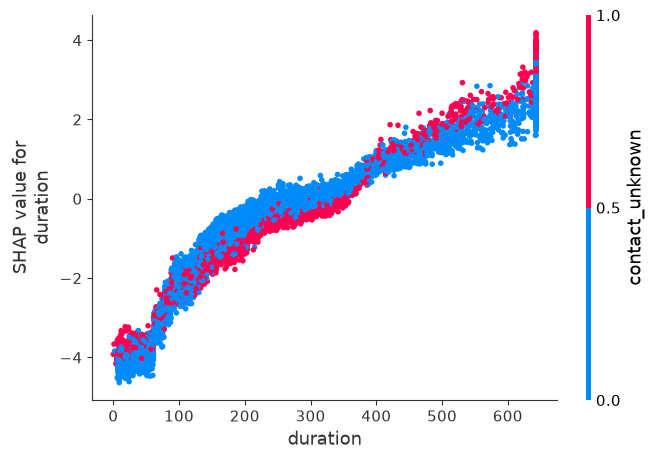

In [450]:
shap.dependence_plot(
    "duration",
    shap_values,
    X_test
)

#### Permutation Importance Analysis

In [454]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    cb_tuned,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

permutation_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean
})

permutation_importance = permutation_importance.sort_values(
    by='Importance',
    ascending=False).head(10).reset_index(drop=True)

permutation_importance

,Feature,Importance
0,duration,0.220531
1,contact_unknown,0.028429
2,day,0.028280
3,month_may,0.009270
4,month_jul,0.008743
5,month_aug,0.007134
6,month_nov,0.006803
7,poutcome_unknown,0.006743
8,poutcome_success,0.006663
9,housing_yes,0.005885


#### Permutation Importance Analysis

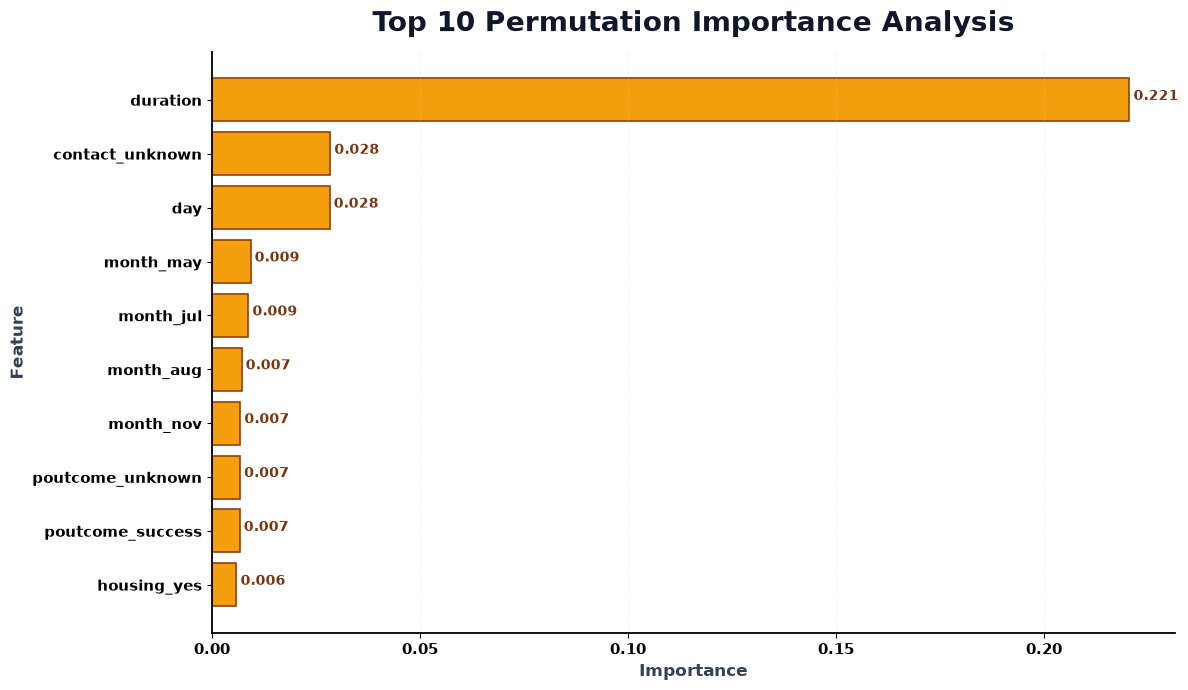

In [467]:
top_10_perm = permutation_importance.sort_values(
    by='Importance',
    ascending=True).head(10)

plt.figure(figsize=(12,7))

bars = plt.barh(
    top_10_perm['Feature'],
    top_10_perm['Importance'],
    color='#F59E0B',
    edgecolor='#92400E',
    linewidth=1.2
)

plt.title(
    "Top 10 Permutation Importance Analysis",
    fontsize=20,
    fontweight='bold',
    color='#0F172A',
    pad=15
)

plt.xlabel(
    'Importance',
    fontsize=12,
    fontweight='bold',
    color='#334155'
)

plt.ylabel(
    'Feature',
    fontsize=12,
    fontweight='bold',
    color='#334155'
)

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25,
    color='#CBD5E1'
)

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

# Remove top\right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

# Vale
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        color='#78350F',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

###

#### Final Model Saving

In [469]:
import joblib

joblib.dump(cb_tuned, "final_model_cb_tuned.pkl")

['final_model_cb_tuned.pkl']

#### Saving Feature Columns

In [471]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "Feature_columns.pkl")

['Feature_columns.pkl']

In [472]:
X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

In [502]:
X['job_blue-collar'].unique()

array([0, 1])

#### 

In [473]:
X.columns.tolist()

['age',
 'balance',
 'day',
 'duration',
 'campaign',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_yes',
 'housing_yes',
 'loan_yes',
 'contact_telephone',
 'contact_unknown',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']